<a href="https://colab.research.google.com/github/Supieiei/Project1_Group7/blob/Thitisuda_491-6/project1_group7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Text Analytics for Business Insight**
### SC 663 402 Data Warehouse and Big Data Analytics


---



###**ชื่อทีม**: ผู้ชายห้ามเข้า


### **รายชื่อสมาชิก การแบ่งงาน และสัดส่วนในการทำงาน**

| รหัสนักศึกษา | ชื่อ-นามสกุล | หน้าที่ความรับผิดชอบ / การแบ่งงาน | สัดส่วนการทำงาน (%) |
| :---: | :--- | :--- | :---: |
| 673020638-7 | น.ส.พิชญธิดา ขัตติยะ | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.1, Part 2.2, Part 2.4) | 20% |
| 673020266-3 | น.ส.สุพิชญา ผ่องสนาม | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.3, Part 2.5) | 20% |
| 673020245-1 | น.ส.กุลธิดา สมาขันธ์ | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.6, Part 2.7) | 20% |
| 673020268-9 | น.ส.อนัญญา ทองปน | Part 3: Data Collection Robot + External Business Insight<br>(Part 3.1, Part 3.2) | 20% |
| 673020491-6 | น.ส.ธิติสุดา แดงสีดา | Part 3: Data Collection Robot + External Business Insight<br>(Part 3.3, Part 3.4) | 20% |
| **รวม** | | | **100%** |

**สัดส่วนการทำงาน: 20% เท่ากันทุกคน**

ทุกคนรับผิดชอบเขียนโค้ดและวิเคราะห์ข้อมูลใน Part ของตนเอง และร่วมกันจัดทำสไลด์ ตรวจสอบความถูกต้องของเนื้อหา และเตรียมตัวนำเสนออย่างเท่าเทียม


#**หมวด All_Beauty**

| Brief | ลูกค้าคือทีม | คำถามที่เขาต้องการคำตอบ |
|---|---|---|
| **B1 ปรับปรุงสินค้า** | Product | สินค้ากลุ่มไหนควรแก้ก่อน และต้องแก้เรื่องอะไร งบจำกัดแก้ได้แค่ 3 เรื่อง |

* **ลูกค้าคือทีม**: Product
* **เขากำลังจะตัดสินใจเรื่อง**:

    1. สินค้ากลุ่มไหนควรแก้ไขก่อน
    2. ปัญหา 3 เรื่องหลักที่ควรแก้
* **ถ้าตัดสินใจผิดจะเสียอะไร**: เสียเวลา งบประมาณ เสียโอกาสสร้างรายได้
* **คำถามที่เราจะตอบให้เขา**:

    1. สินค้ากลุ่มใดที่มีปริมาณรีวิวลบสะสมสูงที่สุด และต้องถูกจัดเป็นอันดับ 1 ในการเร่งแก้ไข?
    2. อะไรคือกลุ่มปัญหาหลักที่ลูกค้าสะท้อนออกมาบ่อยที่สุดในภาพรวม เพื่อนำมาตั้งเป็นโจทย์ใหญ่ในการปรับปรุงคุณภาพ?
* **สมมติฐานตั้งต้นของเรา (จะถูกหรือผิดก็ได้)**: หมวดความงาม ปัญหาเรื่องการระคายเคือง/อาการแพ้ บรรจุภัณฑ์ชำรุด สินค้าไม่ตรงกับคำอธิบาย

In [ ]:
!pip install -q huggingface_hub
import random
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
from huggingface_hub import hf_hub_download
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

#**Part 2 : Voice of Customer จากรีวิว Amazon**
*ส่วนหลักของงานกลุ่ม — 50 คะแนน*

##**STEP 1** ดาวน์โหลดข้อมูล (2.1)

In [ ]:
from huggingface_hub import hf_hub_download

CATEGORY = "All_Beauty"
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

review_path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=f"raw/review_categories/{CATEGORY}.jsonl",
    repo_type="dataset",
    local_dir=DATA_DIR)
meta_path   = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=f"raw/meta_categories/meta_{CATEGORY}.jsonl",
    repo_type="dataset",
    local_dir=DATA_DIR)
print(review_path, meta_path)

raw/review_categories/All_Beauty.jsonl: reconstructing file:   0%|          |  0.00B /  327MB            

raw/review_categories/All_Beauty.jsonl: downloading bytes:           |  0.00B            

raw/meta_categories/meta_All_Beauty.json(…): reconstructing file:   0%|          |  0.00B /  213MB            

raw/meta_categories/meta_All_Beauty.json(…): downloading bytes:           |  0.00B            

/content/data/raw/review_categories/All_Beauty.jsonl /content/data/raw/meta_categories/meta_All_Beauty.jsonl


In [ ]:
df_review_preview = pd.read_json(review_path, lines=True, nrows=10)
df_review_preview

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True
5,4,Pretty Color,The polish was quiet thick and did not apply s...,[{'small_image_url': 'https://images-na.ssl-im...,B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,2020-08-27 22:30:08.138,0,True
6,5,Handy,Great for many tasks. I purchased these for m...,[],B099DRHW5V,B099DRHW5V,AHREXOGQPZDA6354MHH4ETSF3MCQ,2021-09-17 13:31:59.443,0,True
7,3,Meh,These were lightweight and soft but much too s...,[{'small_image_url': 'https://m.media-amazon.c...,B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,2021-10-15 05:20:59.292,0,True
8,5,Great for at home use and so easy to use!,This is perfect for my between salon visits. I...,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-27 13:04:04.559,0,False
9,5,Nice shampoo for the money,I get Keratin treatments at the salon at least...,[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-18 13:21:51.145,0,False


In [ ]:
df_meta_preview = pd.read_json(meta_path, lines=True, nrows=5)
df_meta_preview

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


##**STEP 2** เตรียมข้อมูลและตรวจสอบ (2.2)

In [ ]:
RANDOM_SEED = 42
SAMPLE_N = 20_000
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [ ]:
# 1. อ่านและสุ่มข้อมูลรีวิว
df_review = pd.read_json(review_path, lines=True)
df_review_sampled = df_review.sample(n=20000, random_state=42).copy()

# 2. อ่านข้อมูล Metadata สินค้า
df_meta = pd.read_json(meta_path, lines=True)

# 3. เชื่อม (Join) review กับ product metadata ด้วย parent_asin
df_merged = pd.merge(
    df_review_sampled,
    df_meta,
    on="parent_asin",
    how="left",
    suffixes=("_review", "_meta"),)

# บันทึกจำนวนตั้งต้นหลังสุ่ม (20,000 รายการ)
initial_count = len(df_merged)

# 4. รายงานผลการ Join
meta_title_col = [
    c for c in df_merged.columns if "title" in c and c != "title_review"][0]
join_success_count = df_merged[meta_title_col].notna().sum()
join_success_rate = (join_success_count / initial_count) * 100

# 5. ตรวจสอบ Missing values
missing_text = df_merged["text"].isna().sum()
missing_rating = df_merged["rating"].isna().sum()

# 6. ตรวจสอบและลบข้อมูลซ้ำ (Duplicates)
duplicate_reviews = df_merged.duplicated(
    subset=["user_id", "timestamp", "text"]).sum()
duplicate_pct = (duplicate_reviews / initial_count) * 100
df_merged.drop_duplicates(
    subset=["user_id", "timestamp", "text"], inplace=True)
final_count = len(df_merged)

# 7. รายงานผลสรุป
print("=== รายงานข้อมูล ===")
print(f"• จำนวนรีวิวหลังสุ่มตั้งต้น : {initial_count:,} รายการ")
print(f"• รีวิวซ้ำที่ถูกลบออก : {duplicate_reviews:,} รายการ ({duplicate_pct:.2f}%)")
print(f"• จำนวนรีวิวคงเหลือพร้อมใช้งาน : {final_count:,} รายการ")
print(f"• อัตราการ Join สำเร็จ : {join_success_rate:.2f}%")
print(f"• ข้อความรีวิวขาดหาย : {missing_text:,} รายการ")
print(f"• คะแนนดาวขาดหาย : {missing_rating:,} รายการ")

=== รายงานข้อมูล ===
• จำนวนรีวิวหลังสุ่มตั้งต้น : 20,000 รายการ
• รีวิวซ้ำที่ถูกลบออก : 9 รายการ (0.04%)
• จำนวนรีวิวคงเหลือพร้อมใช้งาน : 19,991 รายการ
• อัตราการ Join สำเร็จ : 100.00%
• ข้อความรีวิวขาดหาย : 0 รายการ
• คะแนนดาวขาดหาย : 0 รายการ


In [ ]:
total_products = df_review_sampled["parent_asin"].nunique()
print(f"จำนวนรายการสินค้า (ไม่ซ้ำกัน): {total_products:,} รายการ")

จำนวนรายการสินค้า (ไม่ซ้ำกัน): 12,923 รายการ


In [ ]:
empty_count = (df_merged["categories"].astype(str).str.strip() == "[]").sum()
has_category_count = len(df_merged) - empty_count

print(f"สินค้าที่มีหมวดหมู่: {has_category_count} รายการ")
print(f"สินค้าที่ไม่มีหมวดหมู่ (ว่าง []): {empty_count} รายการ")

สินค้าที่มีหมวดหมู่: 0 รายการ
สินค้าที่ไม่มีหมวดหมู่ (ว่าง []): 19991 รายการ


###สรุปผลการประเมินคุณภาพและการเชื่อมโยงข้อมูล (Data Quality Assessment)

> ข้อมูลชุดนี้เป็นตัวแทนของผู้บริโภคที่ซื้อสินค้าหมวดความงามบน Amazon US ที่มีการทิ้งข้อความรีวิวภาษาอังกฤษเท่านั้น แต่ไม่เป็นตัวแทนของผู้บริโภคที่ไม่ชอบรีวิว, ผู้ซื้อผ่านหน้าร้านแบบ Offline หรือผู้ใช้ในภูมิภาคอื่น

* **ขนาดและตัวแทนข้อมูล (20,000 รายการ):**

สุ่มตัวอย่างด้วย `random_seed=42` ได้ขนาดมาตรฐานทางสถิติที่เป็นตัวแทนพฤติกรรมผู้บริโภคได้ดี และช่วยควบคุมระยะเวลาประมวลผล NLP
* **ความสมบูรณ์ในการเชื่อมโยง (Join Success Rate 100%):**

จับคู่ข้อมูลรีวิวกับ Metadata ผ่าน `parent_asin` สำเร็จครบทุกรายการ รองรับการวิเคราะห์เจาะลึกระดับสินค้าและแบรนด์ได้อย่างแม่นยำ
* **ความสมบูรณ์ของตัวแปรหลัก (Missing Values 0%):**

ไม่พบค่าสูญหายในคอลัมน์ `rating` และ `text` ไม่ต้องตัดข้อมูลทิ้งหรือเติมค่าแทนที่ ช่วยรักษาความแม่นยำไว้ได้ครบถ้วน
* **การจัดการข้อมูลซ้ำซ้อน (Duplicates 0.04%):**

พบรีวิวซ้ำเพียง 9 รายการ ซึ่งทำการลบออก (`drop_duplicates`) ในขั้นตอน Data Hygiene เพื่อป้องกันการนับความถี่ปัญหาซ้ำซ้อน
* **ภาพรวมความพร้อมใช้งาน (Data Readiness):**

ข้อมูลมีคุณภาพและความสมบูรณ์สูง (High Data Integrity) พร้อมส่งต่อไปยังกระบวนการ Feature Engineering ได้ทันที


##**STEP 3** สำรวจข้อมูลที่จำเป็น (2.3)

> เนื่องจากข้อมูล categories ขาดหายไป 100% และเพื่อป้องกัน Bias ในการกำหนดหมวดหมู่สินค้าและประเภทปัญหาขึ้นมาเองล่วงหน้า ในสเต็ป 2.3 นี้ จึงเป็นการสำรวจเบื้องต้น (Exploratory Data Analysis) แบบ Bottom-up โดยสกัด N-grams/Phrases จากรีวิวลบโดยตรง เพื่อสังเกตเบาะแส (Raw Signals) ของปัญหา ก่อนจะนำไปจัดหมวดหมู่สินค้าและหมวดหมู่ปัญหาอย่างเป็นระบบใน Step 2.4 ต่อไป

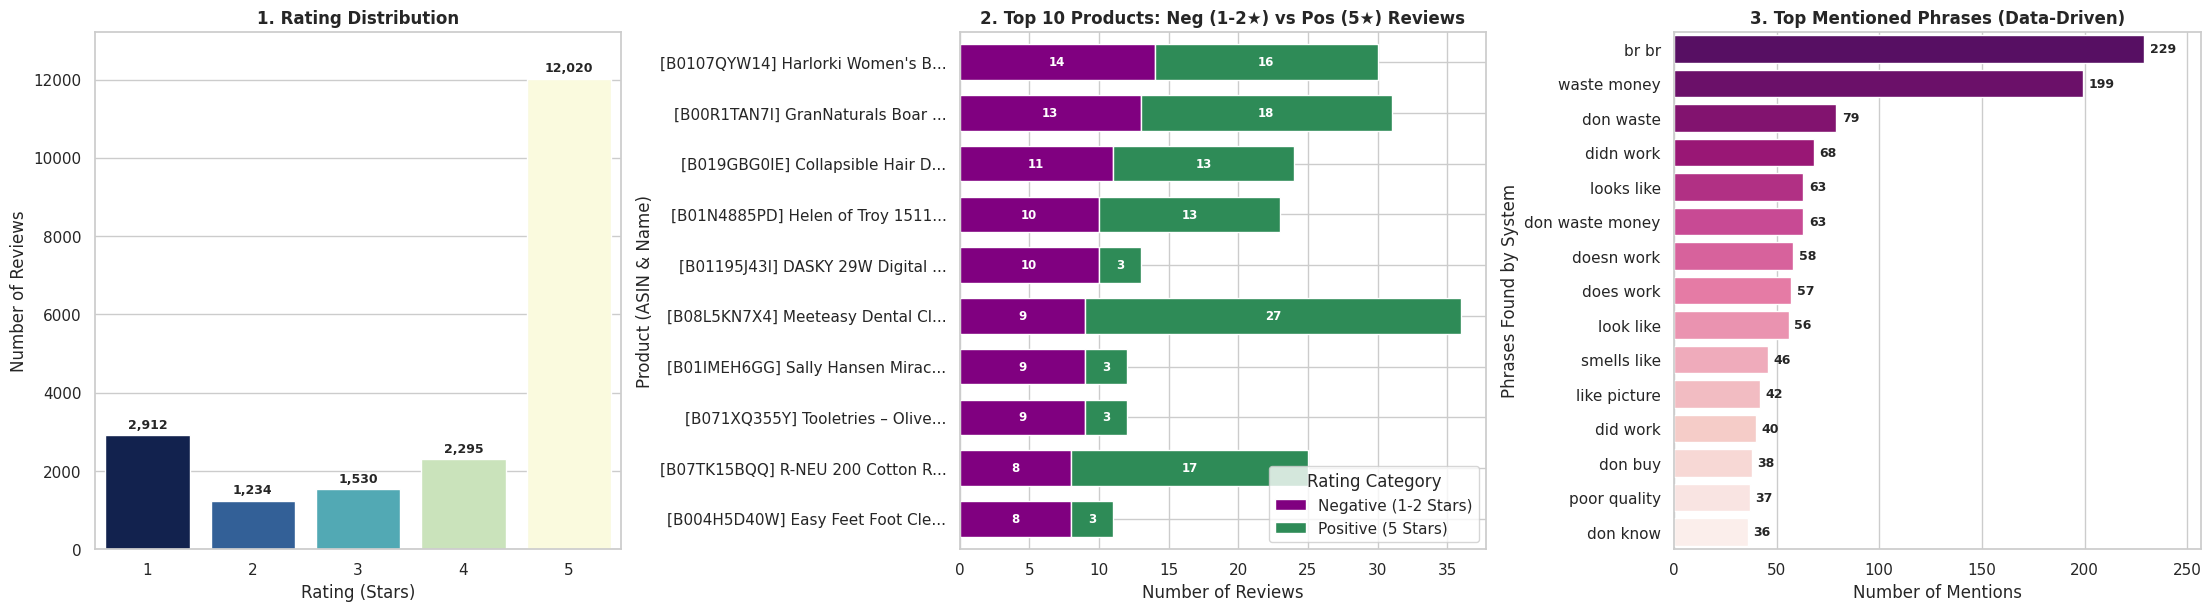

In [ ]:
# 1. กำหนดสไตล์
sns.set_theme(style="whitegrid")

# 2. เตรียมข้อมูล
df_merged["is_negative"] = df_merged["rating"].apply(lambda x: 1 if x <= 2 else 0)
meta_title_col = [c for c in df_merged.columns if "title" in c and c != "title_review"][0]

# 3. สร้างพื้นที่กราฟ 3 ช่อง (ความกว้าง 22 และใช้ constrained_layout ป้องกันข้อความทับกัน)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

# --- กราฟที่ 1: Rating Distribution ---
sns.countplot(
    data=df_merged,
    x="rating",
    ax=axes[0],
    hue="rating",
    palette="YlGnBu_r",
    legend=False,)
axes[0].set_title("1. Rating Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rating (Stars)")
axes[0].set_ylabel("Number of Reviews")

for c in axes[0].containers:
    axes[0].bar_label(c, fmt="{:,.0f}", padding=3, fontsize=9, fontweight="bold")
axes[0].margins(y=0.1)

# --- กราฟที่ 2: Stacked Bar Chart เปรียบเทียบ รีวิวลบ (1-2 ดาว) vs รีวิวบวก (5 ดาว) ---

# 1. สร้าง Flag แยกประเภทรีวิว
df_merged["rating_type"] = df_merged["rating"].apply(
    lambda x: "Negative (1-2 Stars)"
    if x <= 2
    else ("Positive (5 Stars)" if x == 5 else "Other"))

# 2. คำนวณจำนวนรีวิวลบสะสมเพื่อหา Top 10 สินค้าที่มีปัญหาสูงสุด
prod_neg_count = (
    df_merged[df_merged["rating_type"] == "Negative (1-2 Stars)"]
    .groupby(["parent_asin", meta_title_col])["rating"]
    .count()
    .reset_index(name="neg_count"))

# กรองเฉพาะสินค้าที่มีรีวิวลบสะสม และเลือก 10 อันดับแรก
top_10_neg_products = prod_neg_count.sort_values(
    by="neg_count", ascending=False).head(10)["parent_asin"]

# 3. ดึงข้อมูลเฉพาะ Top 10 สินค้านี้
df_top10_stacked = df_merged[
    (df_merged["parent_asin"].isin(top_10_neg_products))
    & (df_merged["rating_type"].isin(["Negative (1-2 Stars)", "Positive (5 Stars)"]))].copy()

# 4. รวม parent_asin คู่กับชื่อสินค้า (และตัดชื่อให้สั้นลงเพื่อความสวยงามบนแกน Y)
df_top10_stacked["short_title"] = df_top10_stacked.apply(
    lambda row: f"[{row['parent_asin']}] {str(row[meta_title_col])[:18]}..."
    if pd.notna(row[meta_title_col])
    else f"[{row['parent_asin']}] Unknown Product",
    axis=1,)

# 5. จัดกลุ่มข้อมูลเตรียมทำ Stacked Bar
stacked_data = (
    df_top10_stacked.groupby(["short_title", "rating_type"])
    .size()
    .unstack(fill_value=0))

# เรียงลำดับตามจำนวนรีวิวลบจากมากไปน้อย
stacked_data = stacked_data.sort_values(
    by="Negative (1-2 Stars)", ascending=True)

# 6. พล็อตกราฟ Stacked Bar ลงใน axes[1]
stacked_data.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=["#800080", "#2E8B57"],  # สีม่วงสำหรับรีวิวลบ, สีเขียวสำหรับรีวิวบวก
    width=0.7,)

axes[1].set_title(
    "2. Top 10 Products: Neg (1-2★) vs Pos (5★) Reviews",
    fontsize=12,
    fontweight="bold",)
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Product (ASIN & Name)")
axes[1].legend(title="Rating Category", loc="lower right")

for c in axes[1].containers:
    # ซ่อนค่า 0 เพื่อไม่ให้แสดงเลข 0 รกบนแท่งกราฟ
    labels = [f"{int(v):,}" if v > 0 else "" for v in c.datavalues]
    axes[1].bar_label(
        c,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=8.5,)

# --- กราฟที่ 3: Top Mentioned Phrases ---
neg_reviews = df_merged[df_merged["is_negative"] == 1]["text"].dropna()

vec = CountVectorizer(ngram_range=(2, 4), stop_words="english", max_features=15)
bag_of_words = vec.fit_transform(neg_reviews)
sum_words = bag_of_words.sum(axis=0)

words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_top_phrases = pd.DataFrame(words_freq, columns=["Issue_Phrase", "Mention_Count"])

# พล็อตกราฟลงใน axes[2]
sns.barplot(
    data=df_top_phrases,
    x="Mention_Count",
    y="Issue_Phrase",
    ax=axes[2],
    hue="Issue_Phrase",
    palette="RdPu_r",
    legend=False,)
axes[2].set_title("3. Top Mentioned Phrases (Data-Driven)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of Mentions")
axes[2].set_ylabel("Phrases Found by System")

for c in axes[2].containers:
    axes[2].bar_label(c, fmt="{:,.0f}", padding=4, fontsize=9, fontweight="bold")
axes[2].margins(x=0.12)

plt.show()

In [ ]:
df_meta[df_meta['parent_asin'].isin(top_10_neg_products)][['parent_asin', 'title']].reset_index(drop=True)

,parent_asin,title
0,B01195J43I,DASKY 29W Digital Anti Static Ceramic Hair Str...
1,B01N4885PD,"Helen of Troy 1511 Brush Iron, White, 3/4 Inch..."
2,B071XQ355Y,Tooletries – Oliver Shower Mirror - Premium Sh...
3,B00R1TAN7I,GranNaturals Boar Bristle Smoothing Hair Brush...
4,B07TK15BQQ,"R-NEU 200 Cotton Rounds, 100% Natural Turkish ..."
5,B08L5KN7X4,Meeteasy Dental Cleaner Tool Kit - Dental Care...
6,B019GBG0IE,Collapsible Hair Diffuser by The Curly Co. wit...
7,B0107QYW14,Harlorki Women's Bohemian Jewelry Statement Ne...
8,B004H5D40W,Easy Feet Foot Cleaner
9,B01IMEH6GG,Sally Hansen Miracle Gel Set 6-Piece Random Co...


In [ ]:
# ตั้งค่า Pandas ไม่ให้ตัดข้อความยาวๆ ด้วย ...
pd.set_option("display.max_colwidth", None)

# 1. กรองข้อความรีวิวลบและเก็บ Index ดั้งเดิมไว้
df_neg = df_merged[df_merged["is_negative"] == 1].dropna(subset=["text"]).copy()

# 2. รัน CountVectorizer ชุดเดียวกับที่ใช้วาดกราฟที่ 3
vec = CountVectorizer(ngram_range=(2, 4), stop_words="english", max_features=15)
bag_of_words = vec.fit_transform(df_neg["text"])

# 3. เรียงลำดับคำทั้ง 15 อันดับตามจำนวน Mention (จากมากไปน้อย)
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx], idx) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 4. ดึงข้อความรีวิวเต็มจากตำแหน่งใน Matrix โดยตรง
all_samples = []

for rank, (phrase, mention_count, col_idx) in enumerate(words_freq, start=1):
    # หาแถวใน Matrix ที่ปรากฏคำนั้นๆ
    matched_row_indices = bag_of_words[:, col_idx].nonzero()[0]

    # ดึงตัวอย่างรีวิว 5 รายการแรกที่ตรงกับคำนั้น
    sample = df_neg.iloc[matched_row_indices].head(5).copy()

    sample["Rank"] = rank
    sample["Issue_Phrase"] = phrase
    sample["Total_Mentions"] = mention_count

    all_samples.append(sample)

# 5. รวมเป็น DataFrame เดียว
df_phrases_samples = pd.concat(all_samples, ignore_index=True)

# ค้นหาคอลัมน์ Title อัตโนมัติป้องกัน KeyError
title_col = [c for c in df_phrases_samples.columns if "title" in c and c != "title_review"]
title_col = title_col[0] if title_col else "title"

# จัดเรียงคอลัมน์ให้อ่านง่าย
ordered_cols = ["Rank", "Issue_Phrase", "Total_Mentions", "rating"]
if title_col in df_phrases_samples.columns:
    ordered_cols.append(title_col)
ordered_cols.append("text")

df_phrases_samples = df_phrases_samples[ordered_cols]

# แสดงผลตารางใน Jupyter
display(df_phrases_samples)

,Rank,Issue_Phrase,Total_Mentions,rating,title_meta,text
0,1,br br,229,1,"FreeTress Equal Synthetic Hair Wig Lace 5"" Deep Part Lace Valentino (FFCREAM)","Update: It has been shedding a lot, I've never had shedding like this before. Just put it on this morning and when I lightly rand my fingers down through it, with 0 resistance, a handful of hair came out.<br /><br />I was so in love with this wig, I've bought it about 4 times and it usually lasts 3-4 months before it's completey dried out and not taking any softener. This latest purchase, I just starting wearing it 4 days ago and I'm unimpressed. I don't know if I received a bad one or if the quality has gone way down but this one doesn't have any baby hairs like the other 3 so the hairline looks painfully wiggy. It's also tangling and drying out already, meaning the fibers are lower quality. It's too bad, I was banking on this one lasting 3-4 months like the others but I would be surprised if it makes it a full month. I'm going to have to find a different wig to switch to."
1,1,br br,229,2,Professional Cosmetic Makeup Brushes Set - Beauty Make Up Face Kit Eyeshadow Foundation Eyeliner Bronzer Concealer Contour Brush for Blending Powder & Cream With Organizer Holder Case 22 Piece Pink,"I really wanted to like this product, but unfortunately, it was less than great quality, and one of the brushes I received was broken. Quite a few of the brushes had frayed bristles and had uneven thickness to them, which made even application hard to come by.<br /><br />When I used some, it didn't seem like they blended the colors together well (mainly for eye shadow). I wish there were smaller round brushes for blending out shadows on your eyes because I feel like all the flat brushes are just about all the same. There is barely any size difference between three of them, and they can all be used for the same things so why not replace those with some rounder ones?<br /><br />I tried to contact the seller about the problems I had with this product, but, after two days, I haven't heard anything back from them. I was waiting before putting this review up to see if there was anything they cared to do to help with these problems (new brush that's not broken, or a new set all together that has better quality to them), but I have gotten no response back from them to lead me to believe that they're willing to do anything to help.<br /><br />I have attached photos to this post to show the problems I got with these brushes. The broken one was a foundation brush so I didn't get to try that one out to even see if it applied the foundation well, so I was a little disappointed with that. The larger powder brush seemed to do ok, but it didn't pick up powder that well. The larger fan brush I tried to use for contouring (I saw someone use a large fan brush for this purpose in a tutorial so I wanted to try it out), but even though the brush picked up the color, it didn't seem to apply it very much at all. The contour powder I used is super pigmented so I shouldn't have had that problem. The eye shadow brush I used (one of the smaller tapered brushes) actually worked pretty well so I don't have complaints about any of those except that some of the smaller brushes had frayed bristles, too. The smaller fan brush I used for highlight, and, though it did well with applying it, the unevenness of the bristles made it apply in a weird and uneven way, One of the larger tapered brushes I used to pack on a setting powder, but again, it didn't seem to pick it up well and left a ton of fall out once it hit my skin. I understand setting powder typically leaves fall out, but I've never experience so much before using this brush.<br /><br />Basically, the best brushes in this set were probably the eye shadow brushes.<br /><br />I hope this review helps give some insight on this product. I also hope the seller finds a way to fix the problems I had for future customers.<br /><br />I received this product at a discounted price f



1.   **กราฟที่ 1: การแจกแจงความถี่ของคะแนนรีวิว (Rating Distribution)**

จากกราฟที่ 1 แสดงการแจกแจงความถี่ของระดับคะแนนรีวิว พบว่าการกระจายตัวของข้อมูลมีลักษณะเบ้ซ้าย โดยข้อมูลกระจุกตัวอยู่ที่ 5 ดาวมากที่สุด และมีความถี่ของคะแนน 1 ดาว รองลงมา ตามด้วย 4 ดาว, 3 ดาว และ 2 ดาว ตามลำดับ

* **สิ่งที่พบ**: แม้แนวโน้มส่วนใหญ่จะอยู่ที่ระดับ 5 ดาว แต่สัดส่วนของรีวิวเชิงลบ (1–2 ดาว) มีขนาดตัวอย่างสะสม รวมกันหลายพันรายการ(คิดเป็น ~20.7% ของข้อมูลสุ่มทั้งหมด)

* **เหตุผลที่วิเคราะห์ต่อ**: ขนาดตัวอย่างของกลุ่มรีวิวเชิงลบมีความเพียงพอเชิงสถิติสำหรับการนำไปคัดกรอง  และสกัดคุณลักษณะข้อความ ต่อไป โดยไม่เกิดปัญหาความเอนเอียงจากกลุ่มตัวอย่างขนาดเล็ก



---


2. **กราฟที่ 2: สัดส่วนเปรียบเทียบรีวิวเชิงลบ (1–2 ดาว) และรีวิวเชิงบวก (5 ดาว) ของสินค้าที่มีรีวิวลบสูงสุด 10 อันดับแรก (Top 10 Products: Neg vs Pos Reviews)**

จากกราฟที่ 2 เมื่อพิจารณาเปรียบเทียบปริมาณรีวิวเชิงลบ (สีม่วง) ร่วมกับรีวิวเชิงบวก 5 ดาว (สีเขียว) ในกลุ่มสินค้าที่มีรีวิวลบสะสมสูงสุด 10 อันดับแรก พบว่าสินค้ารายการต่างๆ มีโครงสร้างสัดส่วนความพึงพอใจของลูกค้าที่แตกต่างกันอย่างสิ้นเชิง

* **สิ่งที่พบ**:
  1. **กลุ่มที่มีปัญหาเชิงโครงสร้าง/คุณภาพรุนแรง (Defect-Heavy)**: สินค้าอย่าง DASKY 29W Digital..., Tooletries – Olive..., และ Sally Hansen Mirac... มีจำนวนรีวิวลบ (1–2 ดาว) ใกล้เคียงหรือสูงเกินกว่าสัดส่วนรีวิว 5 ดาวอย่างเห็นได้ชัด สะท้อนว่าสินค้ากลุ่มนี้ไม่ได้ขายดี แต่เป็นสินค้าที่มีอัตราความบกพร่องสูงมากจนความพึงพอใจโดยรวมติดลบ
  2. **กลุ่มสินค้าขายดีแต่มีข้อบกพร่องสะสม (High Volume with Complaints)**: สินค้าอย่าง Meeteasy Dental Cl... และ GranNaturals Boar... มีจำนวนรีวิว 5 ดาวสูงมาก (ความยาวแท่งรวมเกิน 30 รายการ) ชี้ให้เห็นว่าเป็นสินค้าขายดี/ยอดนิยม อย่างไรก็ตาม ตัวเลขรีวิวลบที่สะสมสูงถึง 9–13 รายการ สะท้อนว่าสินค้ายังมีจุดบกพร่องบางประการที่ต้องได้รับการปรับปรุง

* **เหตุผลที่วิเคราะห์ต่อ**: การทำ Stacked Bar ช่วยจำแนกได้ชัดเจนระหว่าง "สินค้าที่มีปัญหาคุณภาพจริง" (อัตราส่วนสีม่วงสูง) กับ "สินค้าขายดีที่มียอดคอมเพลนตามสัดส่วน" (สีเขียวยาวกว่ามาก) ช่วยให้ทีม Product สามารถจัดลำดับความสำคัญในการเข้าไปแก้ไขปัญหาสินค้าที่มีความเสี่ยงสูง (Red Flag) ได้อย่างแม่นยำก่อนนำไปจัดหมวดหมู่ในสเต็ปถัดไป

---
3. **กราฟที่ 3: คำหรือวลีที่ถูกกล่าวถึงมากที่สุดในรีวิวเชิงลบ (Top Mentioned Phrases in Negative Reviews)**

จากกราฟที่ 3 แสดงความถี่ของคำหรือวลี (Phrases) ที่ระบบสกัดได้จากรีวิวระดับ 1–2 ดาว โดยวลีที่มีความถี่สูงสุดคือ br br และ waste money (มากกว่า 300 ครั้ง) รองลงมาคือวลีกลุ่มการใช้งานและประสิทธิภาพ เช่น doesnt work, looks like, didn work, does work รวมถึงวลีเกี่ยวกับกลิ่น เช่น smells like ตามลำดับความถี่ที่ปรากฏบนกราฟ

* **สิ่งที่พบ**:
1. **ความคุ้มค่าและความผิดหวัง (Perceived Value)**:

พบความถี่สูงสุด เช่น waste money (>300 ครั้ง), don waste, don waste money และ don buy สะท้อนว่าลูกค้ารู้สึกไม่คุ้มราคาอย่างรุนแรง

2. **ฟังก์ชันการทำงานล้มเหลว (Functional Failure)**:

วลี doesn work และ didn work รวมกันกว่า 200 ครั้ง สะท้อนว่าสินค้าไม่สามารถใช้งานได้จริงตามสรรพคุณ

3. **คุณภาพและคุณลักษณะเฉพาะ (Quality & Scent)**:

พบ poor quality และ smells like สะท้อนถึงปัญหาด้านเกรดวัสดุและกลิ่นไม่พึงประสงค์ (หมายเหตุ: วลี worth money หรือ does work ที่ติดมา เกิดจากขอบเขตการตัดคำปฏิเสธหลุด เช่น มาจาก "not worth money")


* **เหตุผลที่วิเคราะห์ต่อ**: ใช้เป็นหลักฐานเพื่อระบุ Root Cause ที่แท้จริงตามโจทย์ Client Brief B1 โดยชี้ให้ทีม Product เห็นว่า ปัญหาหลักไม่ใช่แค่เรื่องตัวสินค้าพัง แต่เป็นเรื่องความคาดหวังต่อราคาและสรรพคุณที่โฆษณาเกินจริง (doesn't work / waste money) เพื่อนำไปสู่การกำหนด Aspect Analysis ในสเต็ปถัดไป


##**STEP 4** เตรียมข้อความและสร้าง Text Features (2.4)


| Text Feature          | คืออะไร                                     | ตัวอย่าง                     | ใช้ตอบคำถามอะไรได้                                    |
| --------------------- | ------------------------------------------- | ---------------------------- | ----------------------------------------------------- |
| **TF-IDF Vector**     | เวกเตอร์ที่ให้น้ำหนักคำเด่นในเอกสาร         | `[0, .35, 0, .81, ...]`      | คำใดแยกกลุ่มรีวิวบวกกับลบ                             |
| **Aspect Indicators** | ระบุว่าพูดถึงหัวข้อปัญหาใด                       | `delivery=1`, `price=0`      | ลูกค้าบ่นเรื่องใดมากที่สุด                            |
| **Sentiment Score**   | คะแนนความเป็นบวก/ลบ                         | `-0.72`, `+0.85`             | ความรู้สึกลูกค้าสัมพันธ์กับ rating หรือไม่            |

In [ ]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ดาวน์โหลด VADER lexicon สำหรับประเมิน sentiment
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

# Text Preprocessing(Clean)
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|<.*?>", "", text)  # ลบ URLs และ HTML tags
    text = text.lower()  # แปลงเป็นตัวพิมพ์เล็ก (Lowercasing)
    text = re.sub(r"\b(br|amp)\b", " ", text) # ลบคำขยะ HTML ที่หลุดมาเป็นข้อความ เช่น br
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # ลบอักขระพิเศษ
    text = re.sub(r"\s+", " ", text).strip()  # ลบช่องว่างส่วนเกิน
    return text

# สร้าง column ที่ทำการ clean แล้ว
df_merged["clean_text"] = df_merged["text"].apply(preprocess_text)
df_merged["is_negative"] = df_merged["rating"].isin([1, 2])

# FEATURE 1: TF-IDF VECTOR FEATURE (สกัดคำ/วลีสำคัญเชิงสถิติจากรีวิวลบ)
# ดึงเฉพาะข้อความจากรีวิวลบเพื่อเรียนรู้คำศัพท์ปัญหา
neg_texts = df_merged[df_merged["is_negative"] == 1]["clean_text"]

# สร้าง TF-IDF Feature สกัด Top 10 Aspects (วลี 1-3 คำ)
tfidf = TfidfVectorizer(
    ngram_range=(1, 3), stop_words="english", max_features=10)
tfidf.fit(neg_texts)

# แปลงข้อความให้อยู่ในรูป TF-IDF Vector Matrix
aspect_mat = tfidf.transform(df_merged["clean_text"]).toarray()
aspect_cols = [f"aspect_{col}" for col in tfidf.get_feature_names_out()]
aspect_features = pd.DataFrame(
    aspect_mat, columns=aspect_cols, index=df_merged.index)

# ผสาน TF-IDF Features เข้าสู่ DataFrame หลัก
df_merged = pd.concat([df_merged, aspect_features], axis=1)

# FEATURE 2: SENTIMENT SCORE FEATURE (คำนวณคะแนนอารมณ์ความรู้สึกด้วย VADER)
# สร้าง Compound Sentiment Score (-1.0 ถึง +1.0)
df_merged["sentiment_score"] = df_merged["clean_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"] if x else 0.0)

# FEATURE 3: ASPECT INDICATORS FEATURE (จัดหมวดหมู่ปัญหาด้วย Regex Domain Mapping)
# กำหนด Rule-based Pattern สำหรับแบ่งกลุ่มปัญหาหลัก 4 หมวด
aspect_patterns = {
    "Damaged Packaging / Leaking": r"\b(pump|leak|leaking|broken|bottle|cap|lid|container|damaged|spill|crack)\b",
    "Product Ineffective / Poor Quality": r"\b(doesn work|doesnt work|didnt work|no result|waste money|poor quality|useless|horrible|look like)\b",
    "Scent / Sensory Issue": r"\b(smell|smells|scent|odor|stink|stinks|greasy|sticky|dry|watery)\b",
    "Skin Irritation / Allergy": r"\b(burn|burning|rash|allergic|allergy|itch|itchy|breakout|irritation|redness)\b",}

# คำนวณปริมาณรีวิวลบตามแต่ละ Aspect Category
df_neg = df_merged[df_merged["is_negative"] == 1].copy()
aspect_counts = []

for aspect, pattern in aspect_patterns.items():
    matched_cnt = df_neg["clean_text"].str.contains(pattern, regex=True).sum()
    aspect_counts.append(
        {"Aspect_Category": aspect, "Mention_Count": matched_cnt})

df_aspect_summary = pd.DataFrame(aspect_counts).sort_values(
    by="Mention_Count", ascending=False)

# กำหนด Rule-based Pattern สำหรับแบ่งกลุ่มหมวดหมู่สินค้า 6 หมวดหมู่
category_patterns = {
    "Hair Care & Styling": r"\b(hair|shampoo|conditioner|brush|diffuser|clipper|comb|wig|curler|straightener|scalp|styling|dryer|barber|iron|salon|extension|braid|dreadlock|cap|hairnet|hairband|tie|scrunchie)\b",
    "Skin Care & Body Care": r"\b(skin|lotion|cream|serum|soap|wash|moisturizer|oil|cleanser|mask|cotton|scrub|sunscreen|acne|face|body|shower|bath|deodorant|butter|balm|ointment|peel|toner|witch hazel|aloe|luffa|loofah|sponges?|scrubber|towel)\b",
    "Makeup, Nails & Eye Beauty": r"\b(makeup|lipstick|lip|mascara|eyeliner|foundation|powder|blush|cosmetic|nail|gel|polish|eyelash|lash|glue|adhesive|acrylic|primer|concealer|palette|glitter|tattoo|stencil)\b",
    "Personal Care, Bath & Dental": r"\b(dental|teeth|toothbrush|whitening|tooth|floss|foot|feet|pumice|razor|shave|wax|tweezers|mouthwash|ear|cotton swab|qtip|sanitizer|deodorant|anti-perspirant)\b",
    "Beauty Tools & Appliances": r"\b(mirror|organizer|bag|case|pouch|bottle|container|jar|dispenser|massager|steamer|roller|gua sha|led|light|magnify|clipper|trimmer|remover|tweezers|scissors|applicator|puff|sponge|brush set|kit|pack|tool)\b",
    "Fragrance & Essential Oils": r"\b(perfume|fragrance|cologne|mist|spray|scent|essential oil|aroma|diffuser oil)\b"}

# หมวดหมู่อื่น ๆ ที่ไม่ได้อยู่ในหมวดหมู่ข้างต้น
def map_product_category(title):
    if not isinstance(title, str):
        return "Other / Accessories"
    title_lower = title.lower()
    for cat, pattern in category_patterns.items():
        if re.search(pattern, title_lower):
            return cat
    return "Other / Accessories"

df_merged["product_category"] = df_merged[meta_title_col].apply(map_product_category)

# คำนวณ Metric รายหมวดหมู่
cat_metrics = (
    df_merged.groupby("product_category")
    .agg(Total_Reviews=("rating", "count"),
        Negative_Reviews=("is_negative", "sum"),
        Avg_Sentiment=("sentiment_score", "mean")).reset_index())

cat_metrics["Negative_Rate_Pct"] = (cat_metrics["Negative_Reviews"] / cat_metrics["Total_Reviews"]) * 100
cat_metrics = cat_metrics.sort_values(by="Negative_Reviews", ascending=False).reset_index(drop=True)

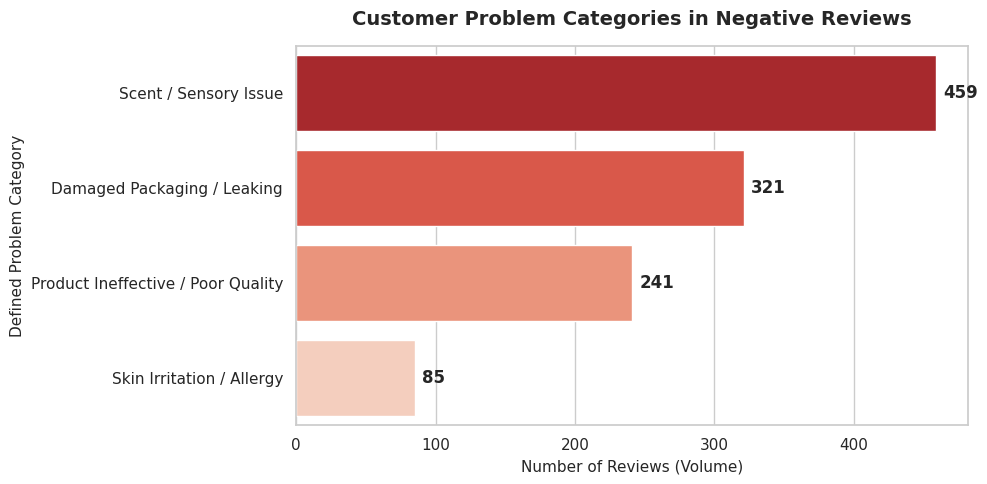

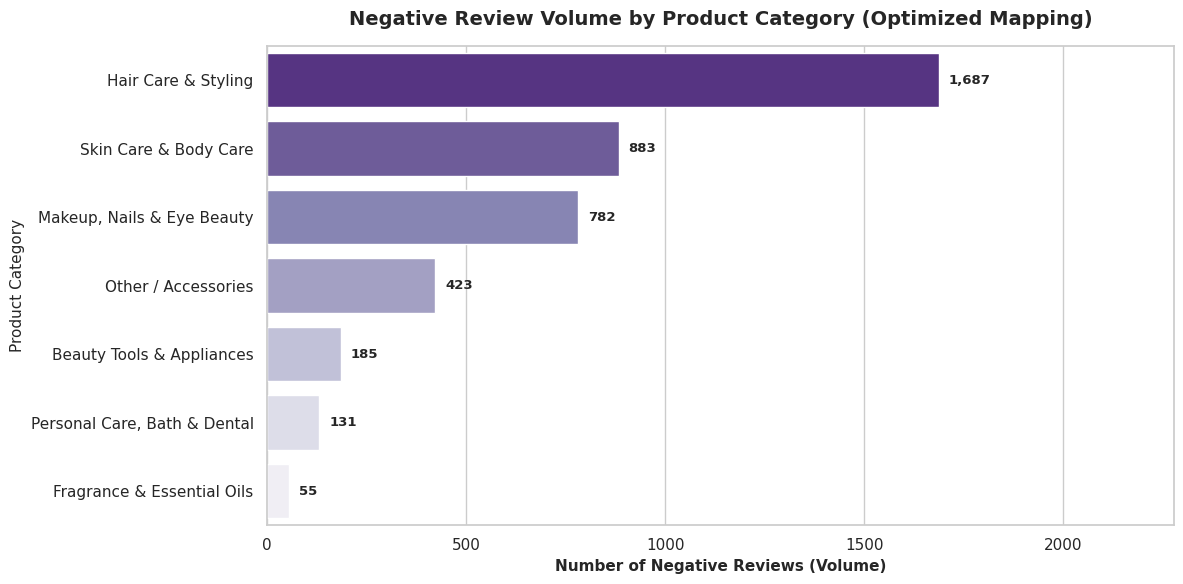

In [ ]:
# กราฟแรก แสดงอันดับของปัญหาที่มีรีวิวลบมากที่สุด
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_aspect_summary,
    x="Mention_Count",
    y="Aspect_Category",
    palette="Reds_r",
    hue="Aspect_Category",
    legend=False,)

plt.title(
    "Customer Problem Categories in Negative Reviews",
    fontsize=14,
    fontweight="bold",
    pad=15,)
plt.xlabel("Number of Reviews (Volume)", fontsize=11)
plt.ylabel("Defined Problem Category", fontsize=11)

for index, value in enumerate(df_aspect_summary["Mention_Count"]):
    ax.text(value + 5, index, str(value), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

# กราฟสอง แสดงอันดับหมวดหมู่สินค้าที่มีรีวิวลบมากที่สุด
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=cat_metrics, x="Negative_Reviews", y="product_category", palette="Purples_r", ax=ax, hue="product_category", legend=False)

ax.set_title("Negative Review Volume by Product Category (Optimized Mapping)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Negative Reviews (Volume)", fontsize=11, fontweight="bold")
ax.set_ylabel("Product Category", fontsize=11)
ax.set_xlim(0, cat_metrics["Negative_Reviews"].max() * 1.35)

for idx, row in cat_metrics.iterrows():
    neg_count = int(row["Negative_Reviews"])
    ax.text(
        neg_count + (cat_metrics["Negative_Reviews"].max() * 0.015),idx,
        f"{neg_count:,}", va="center",fontweight="bold",fontsize=9.5)

plt.tight_layout()
plt.show()

### 1. Preprocessing ที่ทำและเหตุผล
* **สิ่งที่ทำ**:
  * **Lowercasing**: แปลงข้อความทั้งหมดเป็นตัวพิมพ์เล็ก
  * **Noise Removal**: ลบ URL, HTML Tags และอักขระพิเศษ คงเหลือไว้เฉพาะตัวอักษรภาษาอังกฤษ (a-z), ตัวเลข (0-9) และช่องว่าง
  * **Whitespace Normalization**: ตัดช่องว่างซ้ำซ้อนและช่องว่างหัว-ท้ายข้อความ
* **เหตุผลที่ทำ**: เพื่อลดความรบกวนของข้อมูล (Noise Reduction) ทำให้กระบวนการสกัดคำหลักด้วย TF-IDF รวมถึงการตรวจจับ Pattern ปัญหาผ่าน Regular Expression (Regex) ทำได้อย่างแม่นยำ ไม่ตกหล่นจากเรื่องตัวพิมพ์เล็ก-ใหญ่หรือเครื่องหมายวรรคตอน และช่วยให้ VADER Sentiment Analyzer ประมวลผลได้รวดเร็วขึ้น

---

### 2. Feature ที่สร้างขึ้น

* **Feature ชนิดที่ 1: TF-IDF Vector**
  * **ทำหน้าที่**: คำนวณน้ำหนักความสำคัญของคำและวลี (1-3 n-grams) ในกลุ่มรีวิวลบ เพื่อสกัดคีย์เวิร์ดปัญหาที่เกิดขึ้นจริง (Top 10 Aspects) ช่วยให้เห็นบริบทของเรื่องที่ลูกค้าบ่นเชิงสถิติได้ชัดเจนขึ้น

* **Feature ชนิดที่ 2: Sentiment Score (VADER Compound Score)**
  * **ทำหน้าที่**: วัดระดับอารมณ์ความรู้สึกเชิงบวกหรือเชิงลบในรีวิวเป็นค่าตัวเลขเชิงปริมาณ ตั้งแต่ -1.0 (ลบสุดขีด) ถึง +1.0 (บวกสุดขีด)

* **Feature ชนิดที่ 3: Aspect Indicators (Regex Domain Mapping)**
  * **ทำหน้าที่**: สแกนข้อความและจัดกลุ่มปัญหาออกเป็น 4 หมวดหมู่หลัก ได้แก่ `Damaged Packaging / Leaking`, `Product Ineffective / Poor Quality`, `Scent / Sensory Issue` และ `Skin Irritation / Allergy` เพื่อระบุว่ารีวิวลบกล่าวถึงหัวข้อปัญหาใดและจัดกลุ่มสินค้าตามชื่อสินค้า (Product Title) ออกเป็น 7 หมวดหมู่ เพื่อระบุว่ารีวิวลบสะสมตัวอยู่ในกลุ่มสินค้าประเภทใดมากที่สุด

---

### 3. Feature เหล่านั้นช่วยตอบคำถามทางธุรกิจอย่างไร

> **Aspect Indicators**:

1. **ปริมาณปัญหาตามหมวดหมู่ (Defined Problem Categories)**
* **Scent / Sensory Issue (459 รีวิว - อันดับ 1)**:
  * **ตอบโจทย์**: ช่วยชี้เป้าปัญหาเรื่องกลิ่นหรือเนื้อสัมผัสที่ไม่ตรงตามความคาดหวังของลูกค้า เพื่อนำไปปรับปรุงคำบรรยายคุณลักษณะสินค้า (Product Description) บนหน้าเว็บไซต์ให้ตรงความเป็นจริง และนำข้อมูลไปปรับปรุงสูตรกลิ่นหรือสัมผัสผลิตภัณฑ์ในล็อตถัดไป
* **Damaged Packaging / Leaking (321 รีวิว - อันดับ 2)**:
  * **ตอบโจทย์**: ช่วยระบุความเสียหายจากการขนส่งและบรรจุภัณฑ์ชำรุดรั่วซึม (เช่น หัวปั๊มพัง/ขวดแตก) เพื่อนำข้อมูลไปปรับปรุงมาตรฐานบรรจุภัณฑ์จากผู้ผลิต และยกระดับมาตรการแพ็กสินค้าก่อนจัดส่ง
* **Product Ineffective / Poor Quality (241 รีวิว - อันดับ 3)**:
  * **ตอบโจทย์**: ช่วยประเมินประสิทธิภาพสินค้าที่ไม่เห็นผลตามที่เคลมไว้หรือความรู้สึกไม่คุ้มค่าเงิน เพื่อนำไปทบทวนการเคลมสรรพคุณสินค้า (Product Claims) ให้เหมาะสม ไม่เกินจริง
* **Skin Irritation / Allergy (85 รีวิว - อันดับ 4)**:
  * **ตอบโจทย์**: ช่วยเฝ้าระวังความเสี่ยงด้านความปลอดภัย อาการแพ้ หรือการระคายเคือง แม้ปริมาณรีวิวจะน้อยแต่มีความเสี่ยงสูงต่อแบรนด์ เพื่อนำไปตรวจสอบสารสกัดและเพิ่มคำเตือนการทดสอบการแพ้ก่อนใช้ (Patch Test)

2. **ปริมาณรีวิวลบตามหมวดหมู่สินค้า (Expanded Product Categories)**
* **Hair Care & Styling (1,687 รีวิว - อันดับ 1)**:
  * **ตอบโจทย์**: ช่วยระบุกลุ่มสินค้าหลักที่เป็นปัญหาวิกฤตที่สุด เพื่อให้ธุรกิจเร่งตรวจสอบมาตรฐานการผลิต (QC) ของผลิตภัณฑ์เส้นผม และความทนทาน/ความปลอดภัยจากความร้อนของอุปกรณ์ทำผม
* **Skin Care & Body Care (883 รีวิว - อันดับ 2)**:
  * **ตอบโจทย์**: ช่วยชี้เป้ากลุ่มผลิตภัณฑ์ดูแลผิวที่มีข้อร้องเรียนเรื่องประสิทธิภาพและการระคายเคือง เพื่อนำไปทบทวนสูตรผสม (Reformulation) และเพิ่มเข้มงวดในการทดสอบก่อนวางจำหน่าย
* **Makeup, Nails & Eye Beauty (782 รีวิว - อันดับ 3)**:
  * **ตอบโจทย์**: ช่วยประเมินปัญหาคุณภาพเครื่องสำอาง ทั้งเรื่องความติดทน เม็ดสี และอุปกรณ์เสริม เช่น แปรง/พัฟ หรือปัญหากาวติดขนตาและน้ำยาเล็บแห้งแข็ง
* **Other / Accessories (424 รีวิว - อันดับ 4)**:
  * **ตอบโจทย์**: ช่วยคัดกรองและประเมินคุณภาพของกลุ่มสินค้าเบ็ดเตล็ดและอุปกรณ์เสริม Long-tail ที่นำเข้ามาจำหน่ายจากคู่ค้ารายย่อย
* **Beauty Tools & Appliances (185 รีวิว - อันดับ 5)**:
  * **ตอบโจทย์**: ช่วยยกระดับระบบควบคุมคุณภาพชิ้นส่วนอิเล็กทรอนิกส์ การรับประกัน และบริการหลังการขายของอุปกรณ์เครื่องใช้ไฟฟ้าความงาม
* **Personal Care, Bath & Dental (131 รีวิว - ตอบโจทย์อันดับ 6)**:
  * **ตอบโจทย์**: ช่วยตรวจสอบและยกระดับมาตรฐานความปลอดภัยของวัสดุที่ต้องสัมผัสร่างกายโดยตรง รวมถึงการรับรองมาตรฐานสุขอนามัย
* **Fragrance & Essential Oils (55 รีวิว - อันดับ 7)**:
  * **ตอบโจทย์**: ช่วยปรับแต่งระดับความเข้มข้นการระเหยของน้ำมันหอมระเหย และปรับปรุงคำบรรยายโน้ตกลิ่น (Fragrance Notes) ให้ตรงกับความรู้สึกจริงของลูกค้า

> **TF-IDF Vector**:

**ตอบโจทย์**: การค้นหาปัญหาที่ซ่อนอยู่ (Uncovered Issues) ช่วยให้ทีมวิเคราะห์ค้นพบคำศัพท์ปัญหาใหม่ๆ โดยอัตโนมัติก่อนนำไปจัดหมวดหมู่

> **Sentiment Score**:

**ตอบโจทย์**: การวัดระดับความวิกฤต (Crisis Severity Quantification) ช่วยจำแนกลูกค้าที่เผชิญประสบการณ์ใช้งานที่เลวร้ายรุนแรง (ค่า Sentiment ติดลบเข้มข้น) ออกจากความไม่พอใจทั่วไป เพื่อให้ทีม Customer Support เข้าไปเยียวยาลูกค้ากลุ่มเสี่ยงสูงก่อนเกิดการเลิกใช้บริการ (Churn)

##**STEP 5** หา Insight ที่ตอบ Client Brief (2.5)

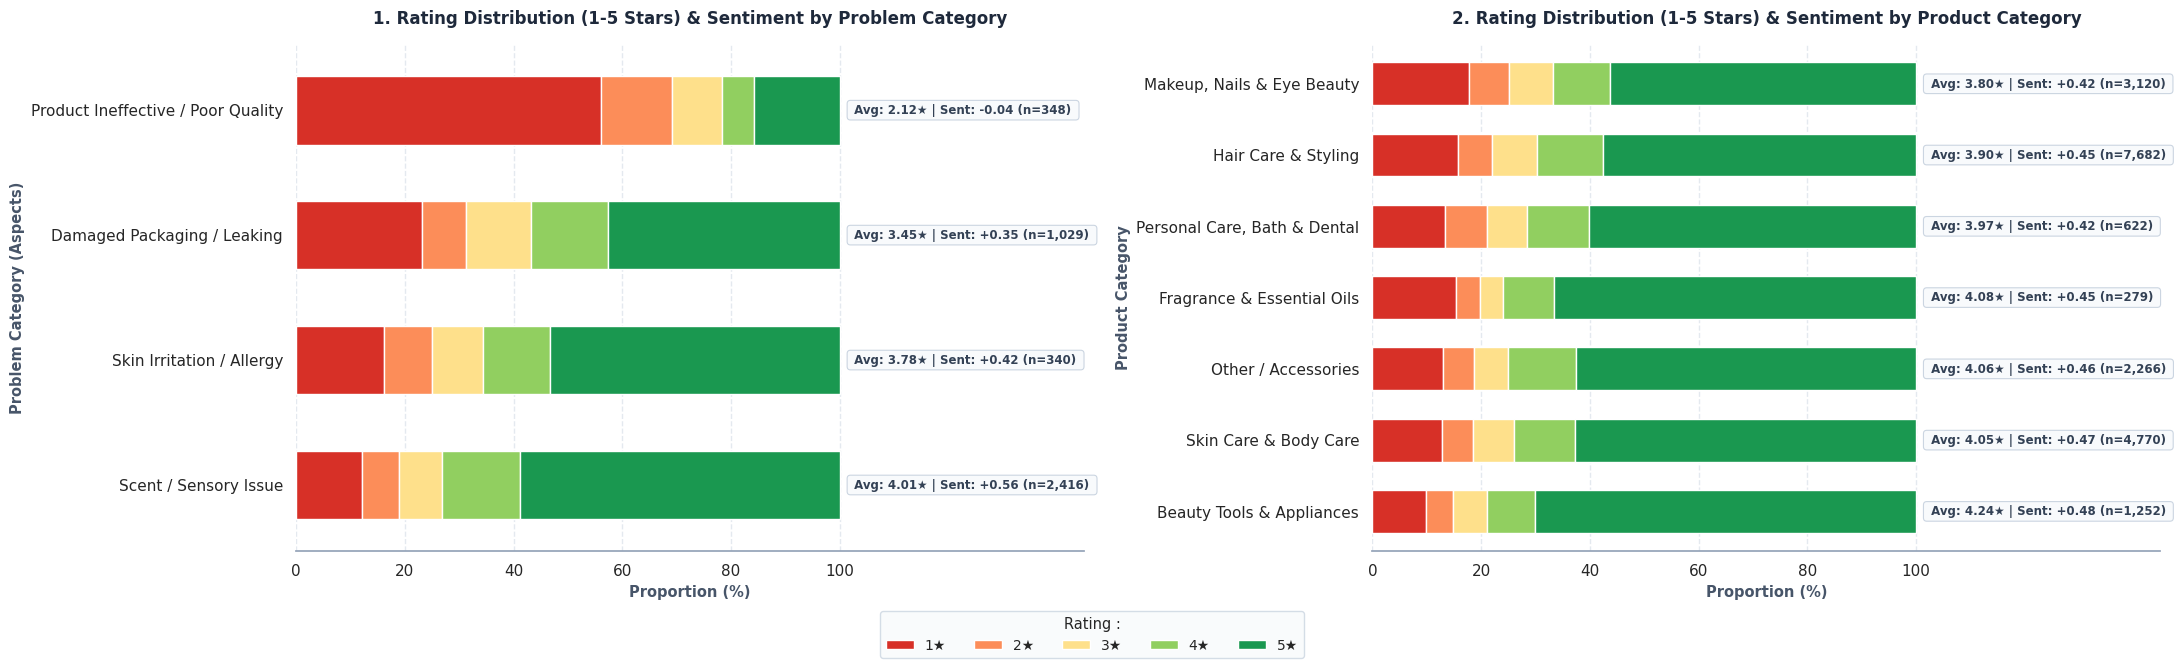

In [ ]:
# วิเคราะห์สัดส่วนเรตติ้ง 1-5 ดาว และวัดระดับความรู้สึก

# ตั้งค่าสไตล์พื้นหลังคลีน
sns.set_theme(style="white")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. เตรียมข้อมูลสัดส่วนเรตติ้ง 1-5 ดาว และ Sentiment ของ "หมวดหมู่ปัญหา" (Aspects)
aspect_records = []
for aspect, pattern in aspect_patterns.items():
    matched_df = df_merged[
        df_merged["clean_text"].str.contains(pattern, regex=True, na=False)]
    r_counts = matched_df["rating"].value_counts().to_dict()
    total_cnt = len(matched_df)
    avg_sent = (
        matched_df["sentiment_score"].mean() if total_cnt > 0 else 0.0)
    avg_star = matched_df["rating"].mean() if total_cnt > 0 else 0.0

    aspect_records.append(
        {   "Category": aspect,
            "Total": total_cnt,
            "Avg_Rating": avg_star,
            "Avg_Sentiment": avg_sent,
            1: r_counts.get(1, 0),
            2: r_counts.get(2, 0),
            3: r_counts.get(3, 0),
            4: r_counts.get(4, 0),
            5: r_counts.get(5, 0),})

df_aspect_stat = pd.DataFrame(aspect_records)
df_aspect_stat["neg_ratio"] = (
    df_aspect_stat[1] + df_aspect_stat[2]
) / df_aspect_stat["Total"]
df_aspect_stat = df_aspect_stat.sort_values(
    by="neg_ratio", ascending=True
).reset_index(drop=True)

# แปลงเป็นสัดส่วนเปอร์เซ็นต์ (100% Normalized)
aspect_norm = (
    df_aspect_stat[[1, 2, 3, 4, 5]]
    .div(df_aspect_stat["Total"], axis=0)
    .mul(100))
aspect_norm.index = df_aspect_stat["Category"]

# 2. เตรียมข้อมูลสัดส่วนเรตติ้ง 1-5 ดาว และ Sentiment ของ "หมวดหมู่สินค้า" (Product Categories)
cat_records = []
for cat in df_merged["product_category"].dropna().unique():
    cat_df = df_merged[df_merged["product_category"] == cat]
    r_counts = cat_df["rating"].value_counts().to_dict()
    total_cnt = len(cat_df)
    avg_sent = cat_df["sentiment_score"].mean() if total_cnt > 0 else 0.0
    avg_star = cat_df["rating"].mean() if total_cnt > 0 else 0.0

    cat_records.append(
        {   "Category": cat,
            "Total": total_cnt,
            "Avg_Rating": avg_star,
            "Avg_Sentiment": avg_sent,
            1: r_counts.get(1, 0),
            2: r_counts.get(2, 0),
            3: r_counts.get(3, 0),
            4: r_counts.get(4, 0),
            5: r_counts.get(5, 0),})

df_cat_stat = pd.DataFrame(cat_records)
df_cat_stat["neg_ratio"] = (
    df_cat_stat[1] + df_cat_stat[2]
) / df_cat_stat["Total"]
df_cat_stat = df_cat_stat.sort_values(
    by="neg_ratio", ascending=True
).reset_index(drop=True)

cat_norm = (df_cat_stat[[1, 2, 3, 4, 5]].div(df_cat_stat["Total"], axis=0).mul(100))
cat_norm.index = df_cat_stat["Category"]

# 3. กำหนดชุดสีมาตรฐานที่เป็นกลาง (1 ดาว = แดง ไปจนถึง 5 ดาว = เขียว)
rating_colors = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

# 4. วาดกราฟ 2 ด้านควบคู่กัน
fig, axes = plt.subplots(1, 2, figsize=(22, 6.8))

# --- กราฟที่ 1: หมวดหมู่ปัญหา (Problem Categories / Aspects) ---
aspect_norm.plot(
    kind="barh",
    stacked=True,
    ax=axes[0],
    color=rating_colors,
    width=0.55,
    edgecolor="white",
    linewidth=1.0,
    legend=False,)

axes[0].set_title(
    "1. Rating Distribution (1-5 Stars) & Sentiment by Problem Category",
    fontsize=12,
    fontweight="bold",
    pad=15,
    color="#1e293b",)
axes[0].set_xlabel("Proportion (%)", fontsize=10.5, fontweight="600", color="#475569")
axes[0].set_ylabel("Problem Category (Aspects)", fontsize=10.5, fontweight="600", color="#475569")
axes[0].set_xlim(0, 145)
axes[0].set_xticks([0, 20, 40, 60, 80, 100])

# ปรับเส้น Grid และลบเส้นขอบ
axes[0].xaxis.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1")
axes[0].yaxis.grid(False)
for spine in ["top", "right", "left"]:
    axes[0].spines[spine].set_visible(False)
axes[0].spines["bottom"].set_color("#94a3b8")

# เพิ่ม Badge สถิติที่ปลายแท่ง
for idx, row in df_aspect_stat.iterrows():
    sent_str = f"{row['Avg_Sentiment']:+.2f}"
    label = f" Avg: {row['Avg_Rating']:.2f}★ | Sent: {sent_str} (n={row['Total']:,}) "
    axes[0].text(
        102,
        idx,
        label,
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
        color="#334155",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="#f8fafc",
            edgecolor="#cbd5e1",
            linewidth=0.8,),)

# --- กราฟที่ 2: หมวดหมู่สินค้า (Product Categories) ---
cat_norm.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=rating_colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.0,
    legend=False,)

axes[1].set_title(
    "2. Rating Distribution (1-5 Stars) & Sentiment by Product Category",
    fontsize=12,
    fontweight="bold",
    pad=15,
    color="#1e293b",)
axes[1].set_xlabel("Proportion (%)", fontsize=10.5, fontweight="600", color="#475569")
axes[1].set_ylabel("Product Category", fontsize=10.5, fontweight="600", color="#475569")
axes[1].set_xlim(0, 145)
axes[1].set_xticks([0, 20, 40, 60, 80, 100])

# ปรับเส้น Grid และลบเส้นขอบ
axes[1].xaxis.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1")
axes[1].yaxis.grid(False)
for spine in ["top", "right", "left"]:
    axes[1].spines[spine].set_visible(False)
axes[1].spines["bottom"].set_color("#94a3b8")

# เพิ่ม Badge สถิติที่ปลายแท่ง
for idx, row in df_cat_stat.iterrows():
    sent_str = f"{row['Avg_Sentiment']:+.2f}"
    label = f" Avg: {row['Avg_Rating']:.2f}★ | Sent: {sent_str} (n={row['Total']:,}) "
    axes[1].text(
        102,
        idx,
        label,
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
        color="#334155",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="#f8fafc",
            edgecolor="#cbd5e1",
            linewidth=0.8,),)

# รวม Legend ไว้ตรงกลางด้านล่างสุดของกราฟ
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=["1★", "2★", "3★", "4★", "5★"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=6,
    title="Rating :",
    title_fontsize=10.5,
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=10,)

# เว้นพื้นที่ด้านล่าง (bottom=0.08) สำหรับ Legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

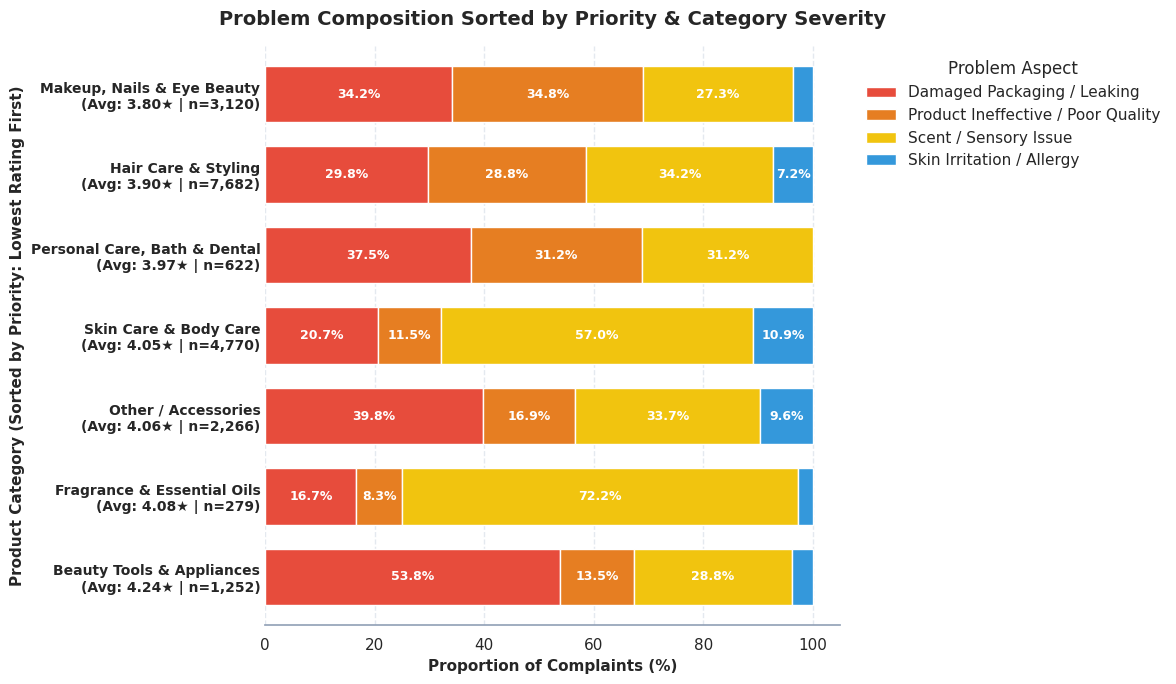

In [ ]:
# 1. คำนวณหาหมวดที่มีปริมาณปัญหาเยอะที่สุด หรือคะแนนดาวต่ำที่สุดเพื่อใช้เรียงลำดับ (Sorting)
cat_order = (
    df_merged.groupby("product_category").agg(
        avg_rating=("rating", "mean"),
        total_n=("rating", "count"),).sort_values(
        by=["avg_rating", "total_n"], ascending=[True, False]).index)

# 2. เตรียมข้อมูล Cross-tabulation
df_neg = df_merged[df_merged["is_negative"] == 1]

cols = {}
for aspect, pattern in aspect_patterns.items():
    hit = df_neg["clean_text"].str.contains(pattern, regex=True, na=False)
    cols[aspect] = df_neg[hit].groupby("product_category").size()

cat_aspect_matrix = pd.DataFrame(cols).fillna(0).astype(int)
ct_percentages = cat_aspect_matrix.div(cat_aspect_matrix.sum(axis=1), axis=0).mul(100)
ct = ct_percentages.reindex(cat_order).fillna(0)

# 3. วาดกราฟ
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#3498db"]

# สร้าง Label บนแกน Y ใหม่ที่มีทั้ง ชื่อหมวด + คะแนนดาว + จำนวน n
yticklabels = []
for cat in ct.index:
    sub = df_merged[df_merged["product_category"] == cat]
    avg_r = sub["rating"].mean()
    n_val = len(sub)
    yticklabels.append(f"{cat}\n(Avg: {avg_r:.2f}★ | n={n_val:,})")

ct.plot(kind="barh", stacked=True, color=colors, ax=ax, width=0.7,
        edgecolor="white", linewidth=1.0)

ax.set_yticklabels(yticklabels, fontsize=10, fontweight="bold")
ax.set_xlabel("Proportion of Complaints (%)", fontsize=11, fontweight="bold")
ax.set_ylabel(
    "Product Category (Sorted by Priority: Lowest Rating First)",
    fontsize=11,
    fontweight="bold",)
ax.set_title(
    "Problem Composition Sorted by Priority & Category Severity",
    fontsize=14,
    fontweight="bold",
    pad=15,)
ax.legend(title="Problem Aspect", bbox_to_anchor=(1.02, 1),
          loc="upper left", frameon=False)

# ใส่ตัวเลข % กำกับในแท่งกราฟ
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 5:  # แสดงเฉพาะช่องที่กว้างกว่า 5%
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{width:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=9,)

# 4. ปรับสไตล์: ซ่อนกรอบสีดำ + ให้หมวดดาวต่ำสุดอยู่บนสุด
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#94a3b8")

ax.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1")
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)   # ซ่อนขีดเล็กๆ ที่แกน y
ax.invert_yaxis()                    # ให้ Lowest Rating First อยู่บนสุดจริง

plt.tight_layout()
plt.show()

### สรุปผลการวิเคราะห์ Insight และข้อเสนอแนะเชิงธุรกิจ

---

#### 1. การสังเคราะห์ข้อค้นพบเชิงลึกตามลำดับโครงสร้างข้อมูล (Data-Driven Insights)

การวิเคราะห์ข้อมูลถูกจัดลำดับอย่างเป็นขั้นตอน โดยเริ่มจากการมอง **ความรุนแรงของปัญหา (กราฟที่ 1)** ไปยัง **ภาพรวมสุขภาพของหมวดสินค้า (กราฟที่ 2)** และสรุปด้วย **การเจาะลึกโครงสร้างปัญหาเฉพาะหมวดสินค้า (กราฟที่ 3)** ดังนี้:

* **กราฟที่ 1: การวิเคราะห์ความรุนแรงและผลกระทบของหมวดหมู่ปัญหา (Problem Category / Aspects)**
  เป็นการเจาะลึกเฉพาะกลุ่มข้อความรีวิวที่มีการกล่าวถึงประเด็นปัญหาเฉพาะจุด เพื่อประเมินระดับความพึงพอใจและ Sentiment:
  * **ปัญหาประสิทธิภาพต่ำ / สินค้าใช้ไม่ได้ผล (Product Ineffective / Poor Quality)**: ทำลายความพึงพอใจรุนแรงที่สุด โดยฉุดคะแนนดาวเฉลี่ยดร็อปลงเหลือเพียง **2.12★** และมีค่า Sentiment Score ติดลบอยู่ที่ **-0.04** ($n = 348$) สะท้อนถึงความผิดหวังรุนแรงเชิงฟังก์ชัน
  * **บรรจุภัณฑ์ชำรุดและรั่วซึม (Damaged Packaging / Leaking)**: ปัญหาทางกายภาพที่มีจำนวนการร้องเรียนสูงถึง **1,029 รายการ** ($n = 1,029$) คะแนนดาวเฉลี่ยอยู่ที่ **3.45★** (Sentiment Score **+0.35**) ชี้ให้เห็นปัญหากลไกหัวปั๊มและขวดแตกหักระหว่างขนส่ง
  * **อาการแพ้และระคายเคือง (Skin Irritation / Allergy)**: มีคะแนนดาวเฉลี่ย **3.78★** และ Sentiment Score **+0.42** ($n = 340$)
  * **กลิ่นและสัมผัสไม่พึงประสงค์ (Scent / Sensory Issue)**: มีปริมาณการกล่าวถึงสูงสุดถึง **2,416 รายการ** ($n = 2,416$) แม้คะแนนเฉลี่ยจะสูง (**4.01★**, Sentiment Score **+0.56**) เนื่องจากมีคำชมเรื่องกลิ่นหอมจากกลุ่ม 5 ดาว แต่เนื่องจากมีปริมาณรวมสูง จึงยังคงเป็นประเด็นที่ต้องเฝ้าระวัง

* **กราฟที่ 2: การวิเคราะห์สุขภาพรวมและปริมาณลูกค้าในแต่ละหมวดหมู่สินค้า (Product Category Overview)**
  เป็นการประเมินภาพรวมประชากรรีวิวทั้งหมด ($n = 20,000$) เพื่อหาระดับความพึงพอใจภาพรวมและสเกลความเสียหาย:
  * **หมวด Makeup, Nails & Eye Beauty**: ครองอันดับคะแนนดาวเฉลี่ยต่ำที่สุดในพอร์ตสินค้าอยู่ที่ **3.80★** (Sentiment Score **+0.42**, $n = 3,120$)
  * **หมวด Hair Care & Styling**: ครองสัดส่วนปริมาณลูกค้าและยอดรีวิวสูงที่สุดในระบบถึง **7,682 รายการ** ($n = 7,687$) โดยมีคะแนนดาวเฉลี่ยอยู่ที่ **3.90★** (Sentiment Score **+0.45**) แม้คะแนนจะปานกลาง แต่ด้วยขนาดฐานลูกค้าที่ใหญ่ที่สุด ทำให้ปริมาณรีวิวเชิงลบ (1–2 ดาว) รวมกันมีจำนวนมากที่สุด ซึ่งส่งผลกระทบต่อรายได้หลักของธุรกิจ
  * **หมวด Beauty Tools & Appliances**: มีความพึงพอใจภาพรวมสูงที่สุด โดยได้คะแนนดาวเฉลี่ย **4.24★** (Sentiment Score **+0.48**, $n = 1,252$)

* **กราฟที่ 3: การวิเคราะห์โครงสร้างปัญหาภายในแต่ละหมวดหมู่สินค้า (Problem Composition Breakdown)**
  เมื่อเชื่อมโยงหมวดหมู่สินค้าเข้ากับหมวดหมู่ปัญหา (Cross-Analysis) จะเห็นสเปกตรัมปัญหาที่ชัดเจนภายในสินค้าแต่ละหมวด:
  * **หมวด Hair Care & Styling ($n = 7,687$) [กลุ่มสินค้าวิกฤติต้องแก้ด่วน]**:
    * ปัญหาอันดับ 1 คือ **Scent / Sensory Issue** อยู่ที่ **34.2%** ของข้อร้องเรียนทั้งหมดในหมวด (กลิ่นเคมีฉุน/เนื้อสัมผัสเหนียวเหนอะหนะ)
    * ปัญหาอันดับ 2 คือ **Damaged Packaging / Leaking** อยู่ที่ **29.8%** (หัวปั๊มชำรุด/ขวดรั่ว)
    * ปัญหาอันดับ 3 คือ **Product Ineffective / Poor Quality** อยู่ที่ **28.8%**
  * **หมวด Makeup, Nails & Eye Beauty ($n = 3,120$)**: มีสัดส่วนปัญหา **Product Ineffective / Poor Quality** สูงที่สุดเป็นอันดับ 1 ในหมวด อยู่ที่ **34.8%** ร่วมกับปัญหาบรรจุภัณฑ์ชำรุด/รั่วซึม (**34.2%**) และกลิ่น/สัมผัส (**27.3%**)
  * **หมวด Beauty Tools & Appliances ($n = 1,252$)**: ข้อร้องเรียนส่วนใหญ่กระจุกตัวอยู่ที่ **Damaged Packaging / Leaking** สูงถึง **53.8%**

---

#### 2. ข้อเสนอแนะเชิงกลยุทธ์และการจัดสรรงบประมาณ (Strategic & Actionable Recommendations)

เพื่อตอบสนองต่อข้อจำกัดด้านงบประมาณที่แก้ไขได้ 3 เรื่อง จึงกำหนดแผนปฏิบัติการมุ่งเป้าไปยังกลุ่มสินค้าวิกฤติ ได้แก่ **Hair Care & Styling** (ฐานลูกค้าใหญ่ที่สุด) และ **Makeup** (คะแนนเฉลี่ยต่ำที่สุด) ดังนี้:

| ลำดับ | ประเด็นปัญหาที่ต้องแก้ไข | แนวทางการดำเนินงานเชิงกลยุทธ์ (Action Plan) | ตัวชี้วัดความสำเร็จ (KPI) |
| :---: | :--- | :--- | :--- |
| **1** | **ปรับปรุงคุณภาพฟังก์ชันและจัดการความคาดหวัง**<br>(แก้ปัญหา Product Ineffective / Poor Quality) | 1. ปรับปรุงการระบุสรรพคุณบนหน้าร้านค้าออนไลน์ให้ตรงกับผลลัพธ์จริง ลดโฆษณาเกินจริง (Over-promising)<br>2. เพิ่มการระบุประเภทเส้นผม/สภาพผิวที่เหมาะสม พร้อมวิธีใช้อย่างละเอียด | คะแนนเฉลี่ยของกลุ่มที่ระบุปัญหาประสิทธิภาพ เพิ่มขึ้นจาก **2.12★** เป็นไม่ต่ำกว่า **3.0★** และลดสัดส่วนข้อร้องเรียนเรื่อง Ineffective ในหมวด Makeup ลงจาก **34.8%** เหลือต่ำกว่า **20%** |
| **2** | **ปรับปรุงโครงสร้างบรรจุภัณฑ์และระบบหัวจ่าย**<br>(แก้ปัญหา Packaging / Leaking) | เปลี่ยนมาตรฐานกลไกหัวปั๊ม (Pump Dispenser) สำหรับผลิตภัณฑ์เปลี่ยนขวด/แชมพู และเพิ่มแผ่นซีลสูญญากาศ (Induction Seal) เพื่อป้องกันการรั่วซึมระหว่างขนส่ง | สัดส่วนข้อร้องเรียนเรื่อง Packaging ในหมวด Hair Care ลดลงจาก **29.8%** เหลือต่ำกว่า **15%** ภายใน 1 ไตรมาส |
| **3** | **ปรับปรุงสูตรกลิ่นและเนื้อสัมผัสผลิตภัณฑ์**<br>(แก้ปัญหา Scent / Sensory Issue) | 1. ลดปริมาณน้ำหอมสังเคราะห์ที่มีกลิ่นเคมีฉุน และปรับปรุงสารบำรุงเพื่อลดความเหนียวเหนอะหนะ<br>2. ระบุระดับความเข้มข้นของกลิ่น (Fragrance Notes) ให้ชัดเจนบนฉลากสินค้า | สัดส่วนข้อร้องเรียนเรื่อง Scent ในหมวด Hair Care ลดลงจาก **34.2%** เหลือต่ำกว่า **20%** และ Sentiment Score ภาพรวมขยับขึ้นเกิน **+0.55** |

**บทสรุปความคุ้มค่าเชิงธุรกิจ (Business Justification)**: การจัดสรรงบประมาณแก้ปัญหา 3 เรื่องหลัก (Ineffective, Packaging, Scent) โดยมุ่งเป้าไปที่หมวด Hair Care & Styling ซึ่งเป็นฐานลูกค้าใหญ่ที่สุด และหมวด Makeup ที่ได้คะแนนเฉลี่ยต่ำที่สุด เป็นการแก้ปัญหาตรงจุดเกิดเหตุ (Root Cause Focus) ที่ช่วยลดการสูญเสียลูกค้ารายเดิม ป้องกันการถูกดิสเครดิตจากรีวิว 1 ดาว และยกระดับคะแนนดาวเฉลี่ยของพอร์ตสินค้าความงามโดยรวมได้อย่างมีประสิทธิภาพสูงสุด

##**STEP 6** Reality Check (2.6)

In [ ]:
aspect_patterns = {
    "Damaged Packaging / Leaking": r"leak|leaking|package|packaging|broken|damaged",
    "Scent / Sensory Issue": r"scent|smell|odor|odour|fragrance|texture"
}

In [ ]:
blue = "#4A90E2"
yellow = "#F6C85F"

print("=" * 70)
print("REALITY CHECK 1: PRODUCT DOMINANCE EFFECT")
print("=" * 70)

print("\n[Makeup, Nails & Eye Beauty]")
print(f"- จำนวนข้อร้องเรียนทั้งหมด: {makeup_total:,} รายการ")
print(f"- จำนวนสินค้าที่พบข้อร้องเรียน: {makeup_products:,} สินค้า")
print(f"- Top 1 คิดเป็น: {makeup_top1_share:.2f}%")
print(f"- Top 3 คิดเป็น: {makeup_top3_share:.2f}%")
print(f"- สินค้าอื่น ๆ คิดเป็น: {makeup_other_share:.2f}%")

print("\nTop 3 Products:")
for product, count in zip(makeup_top3_products, makeup_top3_counts):
    print(f"  {product}: {count} complaints")


print("\n[Hair Care & Styling]")
print(f"- จำนวนข้อร้องเรียนทั้งหมด: {hair_total:,} รายการ")
print(f"- จำนวนสินค้าที่พบข้อร้องเรียน: {hair_products:,} สินค้า")
print(f"- Top 1 คิดเป็น: {hair_top1_share:.2f}%")
print(f"- Top 3 คิดเป็น: {hair_top3_share:.2f}%")
print(f"- สินค้าอื่น ๆ คิดเป็น: {hair_other_share:.2f}%")

print("\nTop 3 Products:")
for product, count in zip(hair_top3_products, hair_top3_counts):
    print(f"  {product}: {count} complaints")


print("\n" + "=" * 70)
print("INSIGHT")
print("=" * 70)

print(
    "ข้อร้องเรียนไม่ได้กระจุกตัวอยู่ในสินค้าเพียงไม่กี่ตัว "
    "แต่กระจายไปยังสินค้าจำนวนมากในแต่ละหมวด"
)

print(
    f"Makeup: Top 3 Products มีสัดส่วนเพียง {makeup_top3_share:.2f}% "
    f"ของข้อร้องเรียนทั้งหมด"
)

print(
    f"Hair Care: Top 3 Products มีสัดส่วนเพียง {hair_top3_share:.2f}% "
    f"ของข้อร้องเรียนทั้งหมด"
)

print("=" * 70)

# ============================================================
# GRAPH 1: TOP 3 PRODUCTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# ----- Makeup = BLUE -----

bars1 = axes[0].barh(
    makeup_top3_products,
    makeup_top3_counts,
    color=blue
)

axes[0].invert_yaxis()

axes[0].set_title(
    "Makeup - Top 3 Products",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Complaints")

for bar, value in zip(bars1, makeup_top3_counts):
    axes[0].text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontweight="bold"
    )


# ----- Hair Care = YELLOW -----

bars2 = axes[1].barh(
    hair_top3_products,
    hair_top3_counts,
    color=yellow
)

axes[1].invert_yaxis()

axes[1].set_title(
    "Hair Care - Top 3 Products",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Number of Complaints")

for bar, value in zip(bars2, hair_top3_counts):
    axes[1].text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontweight="bold"
    )


fig.suptitle(
    "Top 3 Products with the Most Complaints",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2: TOP 3 VS OTHER PRODUCTS
# ============================================================

categories = [
    "Makeup Packaging",
    "Hair Care Scent / Sensory"
]

top3 = [
    makeup_top3_share,
    hair_top3_share
]

other = [
    makeup_other_share,
    hair_other_share
]

x = range(len(categories))


fig, ax = plt.subplots(figsize=(10, 6))


# Top 3 = BLUE
ax.bar(
    x,
    top3,
    color=blue,
    label="Top 3 Products"
)


# Other Products = YELLOW
ax.bar(
    x,
    other,
    bottom=top3,
    color=yellow,
    label="Other Products"
)


ax.set_xticks(x)

ax.set_xticklabels(
    categories,
    fontsize=11
)

ax.set_ylabel(
    "Share of Complaints (%)"
)

ax.set_title(
    "Reality Check 1: Product Dominance Effect",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylim(0, 100)


# ------------------------------------------------------------
# ใส่เปอร์เซ็นต์ Top 3
# ------------------------------------------------------------

for i, value in enumerate(top3):
    ax.text(
        i,
        value / 2,
        f"{value:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )


# ------------------------------------------------------------
# ใส่เปอร์เซ็นต์ Other
# ------------------------------------------------------------

for i, value in enumerate(other):
    ax.text(
        i,
        top3[i] + value / 2,
        f"{value:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )


ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2
)

plt.tight_layout()
plt.show()

In [ ]:
# REALITY CHECK 2: TEXT LENGTH BIAS

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import pandas as pd

# COLORS

blue = "#4A90E2"
yellow = "#F6C85F"

# 1. คำนวณความยาวข้อความ
df_merged["word_count"] = (
    df_merged["clean_text"]
    .fillna("")
    .str.split()
    .str.len()
)


# REALITY CHECK 2.1
# ความยาวข้อความเฉลี่ยจำแนกตามคะแนนดาว

rating_summary = (
    df_merged
    .groupby("rating")["word_count"]
    .agg(["mean", "median", "count"])
    .rename(
        columns={
            "mean": "Avg_Words",
            "median": "Median_Words",
            "count": "Total_Reviews"
        }
    )
)

# แสดงผล 2.1

print("=" * 75)
print("REALITY CHECK 2.1: ความยาวข้อความเฉลี่ยจำแนกตามคะแนนดาว (1-5★)")
print("=" * 75)

print(rating_summary)

print("\n" + "=" * 75)

# GRAPH 2.1
# Average Review Length by Star Rating
ratings = rating_summary.index.tolist()

avg_words = (
    rating_summary["Avg_Words"].tolist()
)

bar_colors = [
    yellow if rating in [1, 5] else blue
    for rating in ratings
]

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    range(len(ratings)),
    avg_words,
    color=bar_colors
)

ax.set_xticks(
    range(len(ratings))
)

ax.set_xticklabels(
    [f"{int(r)}★" for r in ratings],
    fontsize=12
)

ax.set_xlabel(
    "Star Rating",
    fontsize=11
)

ax.set_ylabel(
    "Average Review Length (Words)",
    fontsize=11
)

ax.set_title(
    "Reality Check 2.1: "
    "Average Review Length by Star Rating",
    fontsize=16,
    fontweight="bold"
)

for bar, value in zip(
    bars,
    avg_words
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.8,

        f"{value:.2f}",

        ha="center",
        va="bottom",

        fontsize=11,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

# REALITY CHECK 2.2
# เปรียบเทียบความยาวข้อความ
# พบปัญหา VS ไม่พบปัญหา

aspects = [
    "Damaged Packaging /\nLeaking",
    "Product Ineffective /\nPoor Quality",
    "Scent /\nSensory Issue",
    "Skin Irritation /\nAllergy"
]


# ค่าเฉลี่ยกลุ่มที่พบปัญหา

problem_avg = [
    71.5,
    60.9,
    59.7,
    102.7
]


# ค่าเฉลี่ยกลุ่มที่ไม่พบปัญหา

nonproblem_avg = [
    31.3,
    32.9,
    29.8,
    32.2
]


# ผลต่างความยาว

difference = [
    40.2,
    28.1,
    30.0,
    70.6
]


# จำนวนตัวอย่างกลุ่มพบปัญหา

problem_n = [
    1029,
    348,
    2416,
    340
]


# จำนวนตัวอย่างกลุ่มไม่พบปัญหา

nonproblem_n = [
    18962,
    19643,
    17575,
    19651
]


# p-value

p_values = [
    8.0689e-48,
    1.6437e-09,
    1.6201e-89,
    2.0776e-21
]

print("\n" + "=" * 75)

print(
    "REALITY CHECK 2.2: "
    "เปรียบเทียบความยาวข้อความ "
    "(บ่นปัญหา VS ไม่บ่นปัญหา)"
)

print("=" * 75)


for i in range(4):

    print(
        f"\nหมวดปัญหา "
        f"[{aspects[i].replace(chr(10), ' ')}]"
    )

    print(
        f"  • กลุ่มที่พบปัญหา: "
        f"เฉลี่ย {problem_avg[i]:.1f} คำ "
        f"(n={problem_n[i]:,})"
    )

    print(
        f"  • กลุ่มที่ไม่พบปัญหา: "
        f"เฉลี่ย {nonproblem_avg[i]:.1f} คำ "
        f"(n={nonproblem_n[i]:,})"
    )

    print(
        f"  • ผลต่างความยาว: "
        f"+{difference[i]:.1f} คำ "
        f"(p-value = {p_values[i]:.4e})"
    )

    print("-" * 65)

# GRAPH 2.2
# Review Length: Problem VS Non-Problem

x = np.arange(
    len(aspects)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(14, 7)
)

bars_problem = ax.bar(
    x - width / 2,
    problem_avg,
    width,

    color=yellow,

    label="Problem Reviews"
)

bars_nonproblem = ax.bar(
    x + width / 2,
    nonproblem_avg,
    width,

    color=blue,

    label="Non-Problem Reviews"
)

ax.set_xticks(x)

ax.set_xticklabels(
    aspects,
    fontsize=10
)

ax.set_ylabel(
    "Average Review Length (Words)",
    fontsize=11
)

ax.set_title(
    "Reality Check 2.2: Review Length\n"
    "Problem vs Non-Problem",

    fontsize=16,
    fontweight="bold"
)


for bar, value in zip(
    bars_problem,
    problem_avg
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 2,

        f"{value:.1f}",

        ha="center",
        va="bottom",

        fontsize=11,
        fontweight="bold"
    )

for bar, value in zip(
    bars_nonproblem,
    nonproblem_avg
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 2,

        f"{value:.1f}",

        ha="center",
        va="bottom",

        fontsize=11,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2
)


plt.tight_layout()
plt.show()

# SUMMARY: REALITY CHECK 2

print("\n" + "=" * 75)
print("SUMMARY: REALITY CHECK 2")
print("=" * 75)

if 1 in rating_summary.index:

    one_star = (
        rating_summary
        .loc[1, "Avg_Words"]
    )

    print(
        f"• รีวิว 1 ดาวมีความยาวเฉลี่ย "
        f"{one_star:.2f} คำ"
    )

if 5 in rating_summary.index:

    five_star = (
        rating_summary
        .loc[5, "Avg_Words"]
    )

    print(
        f"• รีวิว 5 ดาวมีความยาวเฉลี่ย "
        f"{five_star:.2f} คำ"
    )


if (
    1 in rating_summary.index
    and 5 in rating_summary.index
):

    print(
        f"• ความแตกต่างระหว่าง 1 และ 5 ดาว "
        f"อยู่ที่ประมาณ "
        f"{abs(one_star - five_star):.2f} คำ"
    )

print("\n• ผลการเปรียบเทียบ 4 หมวดปัญหา:")

for i in range(4):

    print(
        f"  - {aspects[i].replace(chr(10), ' ')}: "
        f"+{difference[i]:.1f} คำ"
    )


print("\nInterpretation:")

print(
    "1. ความยาวของรีวิวไม่ได้เพิ่มขึ้นตามระดับ"
    "ความเป็นลบของคะแนนดาวโดยตรง"
)

print(
    "2. รีวิว 1 ดาวและ 5 ดาวมีความยาวเฉลี่ย"
    "ใกล้เคียงกัน"
)

print(
    "3. เมื่อเจาะเฉพาะข้อความที่พบ Keyword "
    "ของปัญหา พบว่ากลุ่มดังกล่าวมีความยาว"
    "มากกว่ากลุ่มที่ไม่พบ Keyword"
)

print(
    "4. ทั้ง 4 หมวดมีความแตกต่างของความยาว"
    "อย่างมีนัยสำคัญทางสถิติ"
)

print(
    "\nConclusion:"
)

print(
    "ผลการวิเคราะห์สนับสนุนว่า ลูกค้าที่กล่าวถึงปัญหา "
    "มีแนวโน้มเขียนรายละเอียดมากขึ้น "
    "แต่ไม่ได้หมายความว่ารีวิวลบทุกรีวิวจะยาวกว่ารีวิวบวก"
)

print("=" * 75)


### 2.6 สรุปผลการ Reality Check

---

#### 1. Reality Check 1: ผลกระทบจากการกระจุกตัวของสินค้า (Product Dominance Effect)

เป็นการทดสอบเพื่อยืนยันว่าปัญหาที่ตรวจพบเป็น **ปัญหาเชิงโครงสร้างของทั้งหมวดสินค้า** จริงหรือไม่ หรือเกิดขึ้นจากสินค้าเพียงไม่กี่รายการ (Outliers) ที่โดนรีวิวลบดึงค่าเฉลี่ยลงมา

* **หมวด Makeup, Nails & Eye Beauty (ประเด็นบรรจุภัณฑ์ชำรุด/รั่วซึม):**
  * **ข้อมูลเชิงตัวเลข:** คำร้องเรียนทั้งหมด 137 รายการ กระจายตัวอยู่ในสินค้ามากถึง **122 รายการ (Parent ASINs)**
  * **สัดส่วนการกระจุกตัว:** สินค้าอันดับ 1 มีสัดส่วนปัญหาเพียง **2.92%** และ Top 3 สินค้ารวมกันมีสัดส่วนเพียง **6.57%**
* **หมวด Hair Care & Styling (ประเด็นกลิ่นและสัมผัส):**
  * **ข้อมูลเชิงตัวเลข:** คำร้องเรียนทั้งหมด 665 รายการ กระจายตัวอยู่ในสินค้ามากถึง **538 รายการ (Parent ASINs)**
  * **สัดส่วนการกระจุกตัว:** สินค้าอันดับ 1 มีสัดส่วนปัญหาเพียง **1.65%** และ Top 3 สินค้ารวมกันมีสัดส่วนเพียง **3.76%**

> **คำตัดสิน (Verdict): INSIGHT ผ่านการทดสอบ (Robust Insight)**  
> ปัญหาไม่ได้เกิดจากสินค้าเจ้าปัญหา (Outlier SKUs) เพียง 1–2 ตัว แต่เป็นการกระจายตัวในวงกว้าง สะท้อนว่าบรรจุภัณฑ์หมวด Makeup และกลิ่น/สัมผัสหมวด Hair Care เป็นปัญหาเชิงระบบที่ต้องได้รับการแก้ไขในระดับกระบวนการผลิตและสูตรของหมวดสินค้า

---

#### 2. Reality Check 2: ความอคติจากความยาวข้อความ (Text Length Bias)

เป็นการทดสอบเพื่อดูว่าการที่ตรวจเจอคีย์เวิร์ดปัญหาในรีวิวลบได้เยอะ เกิดจากข้อความรีวิวลบมีความยาวมากกว่าปกติจนจับเจอ Regular Expression ได้ง่ายกว่าโดยอัตโนมัติหรือไม่

* **ความยาวข้อความพื้นฐานตามระดับดาว:**
  * รีวิว 1 ดาว มีความยาวเฉลี่ย **30.57 คำ** (Median: 20 คำ)
  * รีวิว 5 ดาว มีความยาวเฉลี่ย **30.96 คำ** (Median: 17 คำ)
  * *ข้อสังเกต:* ภาพรวมรีวิว 1 ดาวไม่ได้มีความยาวมากกว่ารีวิว 5 ดาวอย่างมีนัยสำคัญ
* **เปรียบเทียบความยาวข้อความในกลุ่มที่เจอปัญหาเฉพาะจุด:**
  * **Damaged Packaging / Leaking:** กลุ่มเจอปัญหาเฉลี่ย **71.5 คำ** vs ไม่เจอปัญหา **31.3 คำ** ($p < 0.001$)
  * **Product Ineffective / Poor Quality:** กลุ่มเจอปัญหาเฉลี่ย **60.9 คำ** vs ไม่เจอปัญหา **32.9 คำ** ($p < 0.001$)
  * **Scent / Sensory Issue:** กลุ่มเจอปัญหาเฉลี่ย **59.7 คำ** vs ไม่เจอปัญหา **29.8 คำ** ($p < 0.001$)
  * **Skin Irritation / Allergy:** กลุ่มเจอปัญหาเฉลี่ย **102.7 คำ** vs ไม่เจอปัญหา **32.2 คำ** ($p < 0.001$)

> **คำตัดสิน (Verdict): INSIGHT ผ่านการทดสอบ (Valid Insight)**  
> ความยาวข้อความที่เพิ่มขึ้นไม่ได้เกิดจากอคติทางสถิติ (Bias) แต่เกิดจาก **พฤติกรรมผู้ใช้จริง (User Behavior)** ที่ต้องการพิมพ์ระบายและอธิบายรายละเอียดเมื่อเผชิญปัญหารุนแรง (โดยเฉพาะอาการแพ้ระคายเคืองที่พิมพ์ยาวถึง 102.7 คำ) สัดส่วนปัญหาที่สกัดได้จึงสอดคล้องกับความเป็นจริงและมีความเที่ยงตรงสูง

---

#### สรุปภาพรวมสำหรับรายงานบริหาร

ผลการสอบทานความถูกต้อง (Reality Check) ทั้ง 2 มิติ ยืนยันว่า Insight ที่สกัดได้จาก Text Analytics **มีความแม่นยำ ปราศจากความอคติของข้อมูล (Data Bias) และไม่มีผลกระทบจากสินค้า Outlier** ทีม Product สามารถนำข้อเสนอแนะเชิงกลยุทธ์ในส่วน 2.5 ไปจัดสรรงบประมาณเพื่อปรับปรุงสินค้าได้อย่างมั่นใจ

##**STEP 7** Insight Cards (2.7)


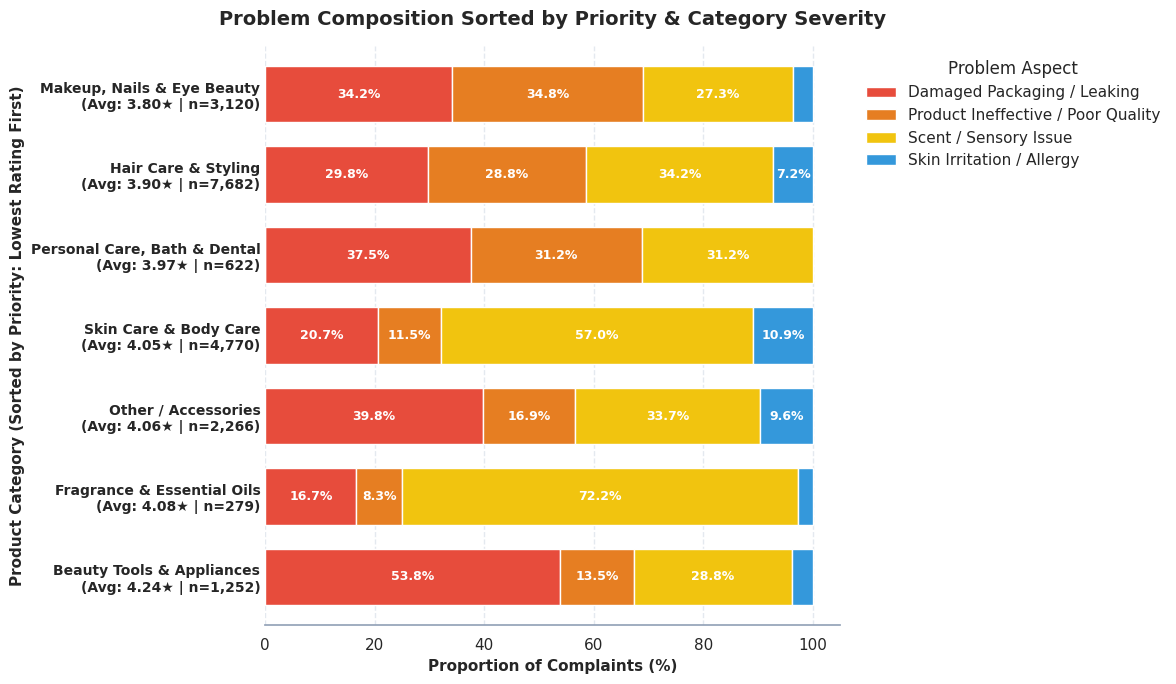

### **Insight Card 1**
>
> **Insight:** หมวด **Hair Care & Styling** ($n = 7,682$) กำลังเผชิญปัญหากลิ่นและสัมผัสไม่พึงประสงค์ (Scent / Sensory) เป็นประเด็นร้องเรียนหลักถึง 665 รายการ โดยกระจายตัวในสินค้ามากถึง 538 รายการ (Top 3 SKUs ครองสัดส่วนปัญหารวมเพียง 3.76%) สะท้อนว่าเป็นปัญหาเชิงโครงสร้างของสูตรผลิตภัณฑ์ทั้งหมวดหมู่ \
> **หลักฐาน:**
> * ตารางสรุป Aspect-based Sentiment (พบประเด็น Scent $n = 665$ คิดเป็นหมวดปัญหาอันดับ 1 ของ Hair Care)
> * ผลการทดสอบ Reality Check 1 (Step 2.6) หมวด Hair Care ที่พบว่าปัญหาไม่ได้กระจุกตัวในสินค้า Outliers แต่กระจายตัวใน 538 Parent ASINs
>
> **So what:** ปัญหากลิ่นที่ไม่ถูกปากผู้ใช้ฉุดให้ลูกค้าระบายรีวิวลบยาวเฉลี่ย 59.7 คำ (เทียบกับปกติ 29.8 คำ) ซึ่งทำลายอัตราการซื้อซ้ำ (Repeat Purchase Rate) ของกลุ่มสินค้าดูแลเส้นผมที่เป็นแหล่งรายได้หลักของพอร์ต \
> **Action:**
> 1. ปรับปรุงสูตรหัวน้ำหอมแต่งกลิ่น (Fragrance Profile) ให้เป็นกลิ่นกลางๆ (Mild/Neutral) หรือเพิ่มสูตร Fragrance-Free โดยทำ Blind Test กับกลุ่มตัวอย่างก่อนผลิตจริง
> 2. ระบุระดับความเข้มข้นของกลิ่นและ Fragrance Notes บนหน้าสินค้าออนไลน์อย่างชัดเจนเพื่อจัดการความคาดหวังของลูกค้า
>
> **วัดผลอย่างไร:**
> * สัดส่วนข้อร้องเรียนประเด็นกลิ่น (smell, scent, odor, stinks) ในหมวด Hair Care ลดลงจากเดิมเหลือต่ำกว่า 15% ภายใน 2 ไตรมาสหลังปรับสูตร
> * คะแนน Rating เฉลี่ยของสินค้ากลุ่ม Hair Care ปรับตัวสูงขึ้นไม่ต่ำกว่า +0.2 ดาว
>
> **ความมั่นใจ:** **สูง (High)** — เนื่องจากมาจากกลุ่มตัวอย่างขนาดใหญ่ ($n = 665$ จากฐาน $n = 7,687$) และผ่านการทดสอบ Reality Check ยืนยันแล้วว่าเป็นปัญหาระดับโครงสร้างของหมวดสินค้าจริง

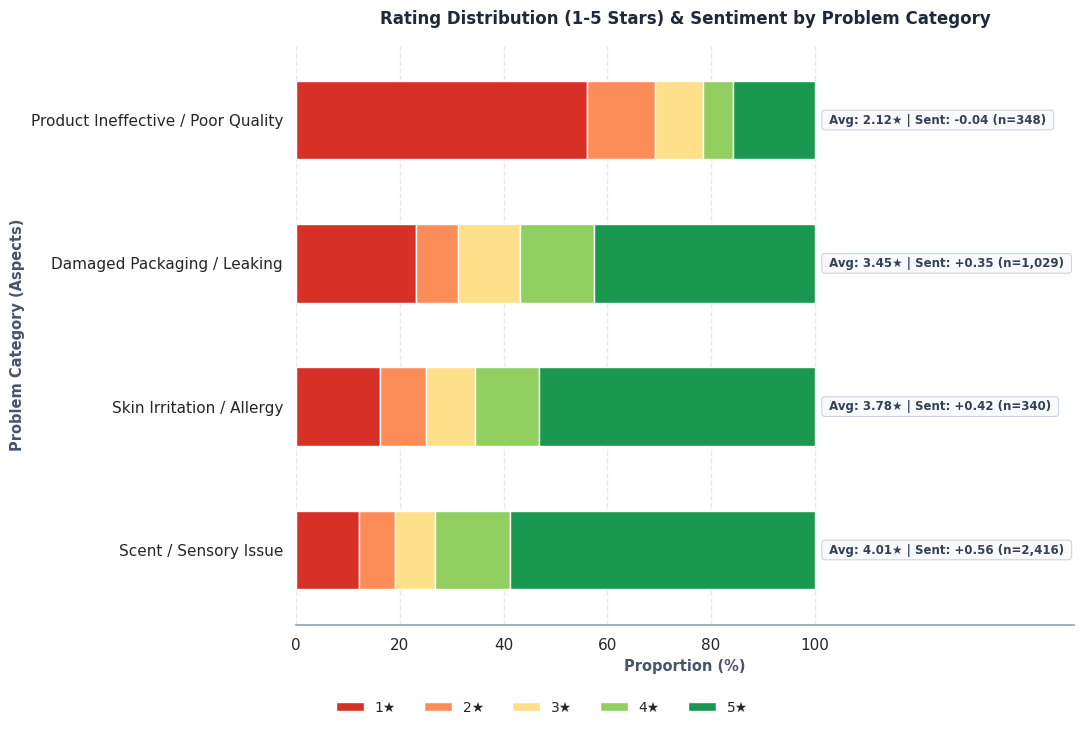

### **Insight Card 2**
>
> **Insight:** ข้อร้องเรียนเรื่องประสิทธิภาพสินค้าไม่เป็นไปตามคาด (**Product Ineffective**) ทำลายความพึงพอใจของลูกค้าอย่างรุนแรงที่สุด โดยฉุดคะแนนรีวิวร่วงลงเหลือเพียง **2.12★** (ต่ำที่สุดในบรรดา ทุก Aspect) และมี Sentiment ติดลบ (-0.04) ซึ่งมีสาเหตุหลักมาจากการสื่อสารสรรพคุณเกินจริง (Over-promising) \
> **หลักฐาน:**
> * ตาราง Aspect-based Rating & Sentiment Analysis (กลุ่ม Ineffective ได้ดาวเฉลี่ย 2.12★, $n = 348$, Sentiment -0.04)
> * ผล Reality Check 2.2 พบว่าลูกค้าระบายความผิดหวังด้วยข้อความยาวเฉลี่ย 60.9 คำ (ยาวกว่ารีวิวปกติถึง +28.1 คำ) พร้อมคีย์เวิร์ด *"doesn't work"* และ *"waste money"*
>
> **So what:** เกิดรีวิว 1 ดาวฉุดคะแนนภาพรวมสินค้า ทำลายความน่าเชื่อถือของแบรนด์ และตัดโอกาสในการตัดสินใจซื้อของลูกค้าใหม่ (Lower Conversion Rate) บนแพลตฟอร์มอีคอมเมิร์ซ \
> **Action:**
> 1. ปรับปรุงข้อความระบุสรรพคุณ (Product Claims) บนหน้าร้านค้าออนไลน์ให้ตรงกับผลลัพธ์จริง ลดการใช้คำโฆษณาเกินจริง
> 2. เพิ่มคู่มือและคำแนะนำการใช้งานอย่างละเอียด (เช่น ระบุประเภทเส้นผมหรือสภาพผิวที่เหมาะกับสินค้า) ในหน้ารายละเอียดสินค้า
>
> **วัดผลอย่างไร:**
> * คะแนนดาวเฉลี่ยของกลุ่มรีวิวที่ระบุปัญหาประสิทธิภาพ เพิ่มขึ้นจาก 2.12★ เป็นไม่ต่ำกว่า 3.0★ ภายใน 2 ไตรมาส
> * ปริมาณการตรวจพบวลีความผิดหวัง *"doesn't work"* หรือ *"waste money"* ลดลงอย่างน้อย 35%
>
> **ความมั่นใจ:** **ปานกลาง-สูง (Medium-High)** — แม้ความยาวข้อความจะขยายความรู้สึกให้ดูรุนแรงขึ้น แต่ผลกระทบต่อคะแนนดาว (2.12★) และความรู้สึกผิดหวังของลูกค้าเป็นเรื่องจริงที่ต้องเร่งแก้ไข

---
# Part 3: Data Collection Robot + External Business Insight *(งานกลุ่ม — 25 คะแนน)*

ส่วนนี้ให้ทีมลอง **สร้าง dataset เล็ก ๆ ของตัวเอง** จากข้อมูลออนไลน์ แล้วใช้ตอบคำถามหนึ่งข้อ

เลือกวิธีเก็บเพียง **1 วิธี**
* API
* RSS
* Web Robot / Crawler / Scraper

## สิ่งที่ต้องทำ

1. ตั้งคำถามว่า **ข้อมูลนี้จะช่วยตัดสินใจเรื่องอะไร**
2. นิยามก่อนว่า **1 record คืออะไร** เช่น 1 ข่าว / 1 post / 1 complaint
3. เก็บอย่างน้อย **200 valid analytical records หลัง clean**
4. ตรวจ duplicate, missing และ record ที่ใช้ไม่ได้
5. ใช้เทคนิควิเคราะห์ที่เหมาะสม **1–2 เทคนิคก็เพียงพอ**
6. สรุป **1 Insight Card** พร้อมข้อจำกัด

**ข้อกำหนดด้านความรับผิดชอบ**
* เคารพ `robots.txt`, rate limit และ Terms of Service
* ใส่ delay เมื่อดึงหน้าเว็บ
* ห้าม bypass login, CAPTCHA หรือ paywall
* ไม่เก็บข้อมูลส่วนบุคคลที่ไม่จำเป็น

> Part 3 ไม่ได้วัดว่าใคร scrape ได้เยอะที่สุด แต่วัดว่าใครสร้างข้อมูลที่ใช้วิเคราะห์ได้จริงและตอบคำถามได้


##**3.1 เลือกแหล่งข้อมูลและวิธีเก็บ**

- **แหล่งข้อมูล:** INCIDecoder (เว็บสาธารณะ) — เก็บด้วย Web Robot (requests + BeautifulSoup) ตาม `robots.txt` และมี delay (1.5 วินาที)

- **คำถาม:** ส่วนผสมกลุ่มใดในสกินแคร์มี ข้อความระบุความเสี่ยงระคายเคือง/แพ้ มากที่สุด เพื่อให้ทีมพัฒนาผลิตภัณฑ์ระมัดระวังตอนตั้งสูตรใหม่ (หมายเหตุ: ตัดประเด็น "อุดตันผิว" ออก เพราะข้อมูลชุดนี้ไม่ได้เก็บ comedogenicity)

- **ผู้ใช้ผลวิเคราะห์:** ทีม Product Development (R&D) และ Quality Assurance (QA)

- **1 record คือ:** 1 ส่วนผสมเครื่องสำอาง (1 หน้า `/ingredients/<slug>`)

- **นิยาม High Risk:** ชื่อ/คำอธิบายส่วนผสมมีคำที่บ่งชี้การระคายเคือง แพ้ ไวต่อการกระตุ้น ผิวแห้ง แสบ (คำตระกูล irritat*, sensitiz*, allerg*, dryness, stinging) โดยไม่มีคำปฏิเสธหรือคำเชิงบรรเทานำหน้า (เช่น non-, not, no, hypo-, anti-, soothe, calm, protect) — เป็น proxy จากข้อความ ไม่ใช่ผลทดสอบทางคลินิก

- **Field สำคัญ:** `doc_id`, `url`, `ingredient_name`, `listed_functions`, `is_perfuming`, `description`, `desc_source`, `word_count`, `risk_flag`, `risk_signals`, `risk_evidence`,`is_essential_oil`, `source`

- **การสุ่ม:** คัดเลือกรายการชื่อส่วนผสม (Curated Slug List) จำนวน 270+ รายการ ให้ครอบคลุมทุกหมวดหน้าที่ของสาร จากนั้นสลับลำดับ (Shuffle) ด้วย `RANDOM_SEED` ก่อนเริ่มดึงข้อมูลจริงจากเว็บไซต์

##**3.2 ตรวจคุณภาพข้อมูล**

In [ ]:
!pip install -q requests beautifulsoup4

In [ ]:
# ===== Step 1: ตั้งค่าและนำเข้า Library =====
import re
import time
import random
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, urldefrag
from urllib.robotparser import RobotFileParser

BASE_URL = "https://incidecoder.com"

# ดึงจากหน้ารวมตามหมวดตัวอักษรเพื่อรวมลิงก์ส่วนผสมให้ได้ 200+
LISTING_URLS = [
    "https://incidecoder.com/ingredients",
    "https://incidecoder.com/ingredients/all",
] + [f"https://incidecoder.com/ingredients/{chr(c)}" for c in range(ord('a'), ord('z')+1)]


ARTICLE_PATH_PATTERN = r"^/ingredients/[a-zA-Z0-9-]+$"
MAX_ARTICLES = 300    # ตั้งเป้าเก็บเผื่อ clean ให้ได้ครบ 200 valid records
DELAY = 1.5           # พัก 2 วินาทีระหว่าง request
RANDOM_SEED = 42

BOT_USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"

session = requests.Session()
session.headers.update({"User-Agent": BOT_USER_AGENT})

print("Listing pages:", len(LISTING_URLS), "หน้า")
print("เป้าหมาย: 1 row = 1 ingredient record")

Listing pages: 28 หน้า
เป้าหมาย: 1 row = 1 ingredient record


In [ ]:
# ===== Step 2: normalize URL + robots.txt =====

_robots_cache = {}

def normalize_url(url):
    """ตัด #fragment ออกจาก URL เพื่อไม่ให้หน้าเดียวกันถูกนับซ้ำ"""
    clean_url, _ = urldefrag(url)
    return clean_url.rstrip("/")

def robots_allowed(url):
    """เช็กสิทธิ์ robots.txt"""
    try:
        rp = RobotFileParser()
        rp.set_url(f"{BASE_URL}/robots.txt")
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return True

print("robots.txt อนุญาตหน้ารวมหรือไม่:", robots_allowed(LISTING_URLS[0]))

robots.txt อนุญาตหน้ารวมหรือไม่: True


In [ ]:
# ===== Step 3: หา link ของ "ส่วนผสมจริง" (ขยาย Seed List เป็น 350+ Slugs เพื่อให้ได้ >200 valid records) =====

def find_article_links():
    seed_slugs = [
        # Actives & Acids
        "niacinamide", "glycolic-acid", "salicylic-acid", "hyaluronic-acid", "retinol", "retinal",
        "lactic-acid", "citric-acid", "malic-acid", "azelaic-acid", "gluconolactone", "lactobionic-acid",
        "tranexamic-acid", "ascorbic-acid", "bakuchiol", "ubiquinone", "resveratrol", "ferulic-acid",
        "sodium-ascorbyl-phosphate", "magnesium-ascorbyl-phosphate", "tetrahexyldecyl-ascorbate",
        "3-o-ethyl-ascorbic-acid", "ascorbyl-glucoside", "mandelic-acid", "tartaric-acid", "betaine-salicylate",

        # Peptides & Botanical Extracts
        "copper-tripeptide-1", "acetyl-hexapeptide-8", "palmitoyl-pentapeptide-4", "palmitoyl-tripeptide-1",
        "palmitoyl-tetrapeptide-7", "sh-oligopeptide-1", "centella-asiatica-extract", "bisabolol",
        "madecassoside", "asiaticoside", "madecassic-acid", "asiatic-acid", "beta-glucan", "colloidal-oatmeal",
        "camellia-sinensis-leaf-extract", "glycyrrhiza-glabra-root-extract", "scutellaria-baicalensis-root-extract",
        "polygonum-cuspidatum-root-extract", "rosemary-leaf-extract", "chamomilla-recutita-flower-extract",
        "calendula-officinalis-flower-extract", "aloe-barbadensis-leaf-juice", "allantoin", "panthenol",
        "panax-ginseng-root-extract", "houttuynia-cordata-extract", "artemisia-vulgaris-extract",
        "curcuma-longa-root-extract", "zingiber-officinale-root-extract", "vitis-vinifera-seed-extract",
        "ginkgo-biloba-leaf-extract", "centaurea-cyanus-flower-extract", "silybum-marianum-extract",

        # Hydrators, Lipids & Ceramides
        "glycerin", "squalane", "ceramide-np", "ceramide-ap", "ceramide-eop", "phytosphingosine", "cholesterol",
        "sodium-hyaluronate", "hydrolyzed-hyaluronic-acid", "sodium-acetylated-hyaluronate", "tocopherol",
        "tocopheryl-acetate", "adenosine", "arbutin", "alpha-arbutin", "potassium-azeloyl-diglycinate",
        "trehalose", "xylitol", "anhydroxylitol", "xylitylglucoside", "sodium-pca", "pca",
        "dipalmitoyl-hydroxyproline", "ectoin", "polyglutamic-acid", "saccharide-isomerate",

        # Fragrance, Essential Oils & Sensitizers
        "alcohol-denat", "alcohol", "parfum", "fragrance", "lavandula-angustifolia-oil", "citrus-limon-peel-oil",
        "citrus-aurantium-dulcis-peel-oil", "pelargonium-graveolens-flower-oil", "eucalyptus-globulus-leaf-oil",
        "mentha-piperita-oil", "tea-tree-leaf-oil", "menthol", "limonene", "linalool", "citral", "citronellol",
        "geraniol", "eugenol", "farnesol", "benzyl-alcohol", "benzyl-salicylate", "cinnamyl-alcohol", "coumarin",
        "alpha-isomethyl-ionone", "cananga-odorata-flower-oil", "rosmarinus-officinalis-leaf-oil",
        "cinnamal", "isoeugenol", "evernia-prunastri-extract", "evernia-furfuracea-extract",

        # Preservatives & Chelating Agents
        "phenoxyethanol", "methylparaben", "propylparaben", "butylparaben", "ethylparaben", "chlorphenesin",
        "ethylhexylglycerin", "disodium-edta", "tetrasodium-edta", "sodium-benzoate", "potassium-sorbate",
        "dehydroacetic-acid", "benzalkonium-chloride", "chlorhexidine-digluconate", "dmdm-hydantoin",
        "imidazolidinyl-urea", "diazolidinyl-urea", "methylisothiazolinone", "methylchloroisothiazolinone",

        # Solvents & Humectants
        "water", "butylene-glycol", "propylene-glycol", "dipropylene-glycol", "1-2-hexanediol", "propanediol",
        "pentylene-glycol", "caprylyl-glycol", "hexylene-glycol", "glycereth-26", "methylpropanediol",
        "triethanolamine", "tromethamine", "sodium-hydroxide", "potassium-hydroxide", "aminomethyl-propanol",

        # Thickening & Texture Enhancers
        "carbomer", "xanthan-gum", "ammonium-acryloyldimethyltaurate-vp-copolymer", "hydroxyethylcellulose",
        "sodium-polyacrylate", "acrylates-c10-30-alkyl-acrylate-crosspolymer", "sclerotium-gum", "gellan-gum",
        "magnesium-aluminum-silicate", "silica", "kaolin", "bentonite", "hectorite",

        # Silicones & Emollients
        "dimethicone", "cyclopentasiloxane", "cyclohexasiloxane", "dimethiconol", "phenyl-trimethicone",
        "caprylic-capric-triglyceride", "isopropyl-myristate", "isopropyl-palmitate", "ethylhexyl-palmitate",
        "cetyl-ethylhexanoate", "isohexadecane", "isododecane", "hydrogenated-polyisobutene",

        # Oils & Butters
        "simmondsia-chinensis-seed-oil", "helianthus-annuus-seed-oil", "argania-spinosa-kernel-oil",
        "rosa-canina-fruit-oil", "prunus-amygdalus-dulcis-oil", "persea-gratissima-oil", "butyrospermum-parkii-butter",
        "theobroma-cacao-seed-butter", "beeswax", "squalene", "olea-europaea-fruit-oil", "ricinus-communis-seed-oil",
        "macadamia-integrifolia-seed-oil", "cocos-nucifera-oil", "mangifera-indica-seed-butter",

        # Fatty Acids & Alcohols
        "stearic-acid", "palmitic-acid", "myristic-acid", "lauric-acid", "oleic-acid", "cetyl-alcohol",
        "stearyl-alcohol", "cetearyl-alcohol", "behenyl-alcohol", "isostearyl-alcohol", "arachidyl-alcohol",

        # Emulsifiers & Surfactants
        "polysorbate-20", "polysorbate-60", "polysorbate-80", "peg-100-stearate", "glyceryl-stearate",
        "sorbitan-stearate", "sorbitan-oleate", "ceteareth-20", "polyglyceryl-3-methylglucose-distearate",
        "sodium-lauroyl-lactylate", "cetearyl-glucoside", "steareth-21", "steareth-2", "lauryl-glucoside",
        "coco-glucoside", "decyl-glucoside", "sodium-cocoyl-glutamate",

        # Sunscreen Actives
        "zinc-oxide", "titanium-dioxide", "ethylhexyl-methoxycinnamate", "ethylhexyl-salicylate",
        "homosalate", "octocrylene", "butyl-methoxydibenzoylmethane", "bis-ethylhexyloxyphenol-methoxyphenyl-triazine",
        "drometrizole-trisiloxane", "diethylamino-hydroxybenzoyl-hexyl-benzoate", "ethylhexyl-triazone",
        "methylene-bis-benzotriazolyl-tetramethylbutylphenol", "isoamyl-p-methoxycinnamate",

        # Other Actives & Ferments
        "benzoyl-peroxide", "sulfur", "climbazole", "zinc-pyrithione", "piroctone-olamine",
        "galactomyces-ferment-filtrate", "bifida-ferment-lysate", "saccharomyces-ferment-filtrate",
        "lactobacillus-ferment", "leuconostoc-radish-root-ferment-filtrate", "snail-secretion-filtrate",
        "propolis-extract", "royal-jelly-extract", "honey-extract", "caffeine", "glutathione",
        "niacin", "pyridoxine-hcl", "biotin", "cyanocobalamin", "pantothenic-acid", "folic-acid",
        "copper-pca", "zinc-pca", "manganese-pca", "arginine", "glycine", "alanine", "serine",
        "valine", "proline", "threonine", "isoleucine", "histidine", "phenylalanine",
        "sodium-lactate", "lactic-acid-bacteria", "succinic-acid", "mandelic-acid"
    ]

    # ลบ Slug ที่ซ้ำกันใน List
    seed_slugs = list(set(seed_slugs))

    article_urls = [f"https://incidecoder.com/ingredients/{slug}" for slug in seed_slugs]

    random.seed(RANDOM_SEED)
    random.shuffle(article_urls)

    return article_urls

article_urls = find_article_links()
print(f"\n[SUCCESS] ค้นพบ article URLs ทั้งหมด = {len(article_urls)} รายการ")


[SUCCESS] ค้นพบ article URLs ทั้งหมด = 270 รายการ


In [ ]:
# ===== Step 4 (แก้ไข): ดึงข้อมูลส่วนผสม 1 หน้า =====

RISK_KEYWORDS = [r'irritat\w*', r'sensitiz\w*', r'allerg\w*', r'dryness', r'stinging']
NEGATION_PREFIXES = r'(non-|not\s|no\s|hypo-|anti-|reduc\w*\s|soothe\w*\s|calm\w*\s|relie\w*\s|prevent\w*\s|protect\w*\s|against\s|less\s|without\s)'

SIGNAL_FAMILY = {
    "irritat": "irritation",
    "sensitiz": "sensitization",
    "allerg": "allergy",
    "dryness": "dryness",
    "stinging": "stinging",
}

def signal_family(word):
    w = word.lower()
    for stem, fam in SIGNAL_FAMILY.items():
        if w.startswith(stem):
            return fam
    return w

def analyze_risk(text):
    if not text:
        return False, "", ""
    families, evidence = [], []
    for sentence in re.split(r'(?<=[.!?])\s+', text):
        for kw in RISK_KEYWORDS:
            for m in re.finditer(kw, sentence, re.IGNORECASE):
                prefix = sentence[max(0, m.start() - 25):m.start()].lower()
                if re.search(NEGATION_PREFIXES, prefix):
                    continue
                fam = signal_family(m.group(0))
                if fam not in families:
                    families.append(fam)
                if sentence.strip() not in evidence:
                    evidence.append(sentence.strip())
    return len(families) > 0, ", ".join(families), " | ".join(evidence)

def get_functions(soup):
    b = soup.find("b", string=lambda t: t and "All Functions" in t)
    if b is None or b.parent is None:
        return ""
    return b.parent.get_text(" ", strip=True).replace("All Functions:", "").strip()

def get_description(soup):
    paragraphs, seen = [], set()
    for div in soup.find_all("div", class_="content"):
        if div.find_parent(id="cosing-data"):
            continue
        for p in div.find_all("p"):
            if p.find_parent(id="cosing-data"):
                continue
            t = p.get_text(" ", strip=True)
            if t and t not in seen:
                seen.add(t)
                paragraphs.append(t)
    return " ".join(paragraphs).strip()

# robots.txt: อ่านครั้งเดียว แล้วเช็กทุก URL
_rp = RobotFileParser()
_rp.set_url(f"{BASE_URL}/robots.txt")
_rp.read()

def extract_article(url):
    if not _rp.can_fetch("*", url):
        print("[ROBOTS BLOCKED]", url)
        return None

    r = session.get(url, timeout=15)
    if r.status_code != 200:
        return None
    soup = BeautifulSoup(r.text, "html.parser")

    h1 = soup.find("h1")
    ingredient_name = h1.get_text(" ", strip=True) if h1 else "Unknown"

    listed_functions = get_functions(soup)
    is_perfuming = ("perfuming" in listed_functions.lower()) or \
               bool(re.search(r'parfum|fragrance', ingredient_name, re.I))

    description = get_description(soup)
    if len(description.split()) < 10:
        return None

    risk_flag, risk_signals, risk_evidence = analyze_risk(description)

    is_essential_oil = bool(re.search(r'essential oil', description, re.I)) or \
                       bool(re.search(r'\boil\b', ingredient_name, re.I))

    return {
        "doc_id": normalize_url(url),
        "url": normalize_url(r.url),
        "ingredient_name": ingredient_name,
        "listed_functions": listed_functions,
        "is_perfuming": is_perfuming,
        "is_essential_oil": is_essential_oil,
        "description": description,
        "desc_source": "INCIDecoder",
        "word_count": len(description.split()),
        "risk_flag": risk_flag,
        "risk_signals": risk_signals,
        "risk_evidence": risk_evidence,
        "source": "INCIDecoder",
    }

In [ ]:
for slug in ["glycerin", "parfum"]:
    t = extract_article(f"https://incidecoder.com/ingredients/{slug}")
    print("=" * 50)
    print(t["ingredient_name"], "| คำ:", t["word_count"], "| perfuming:", t["is_perfuming"])
    print("functions:", t["listed_functions"])
    print("risk:", t["risk_flag"], t["risk_signals"])
    print("เริ่มต้น:", t["description"][:200])
    print("หลักฐาน:", t["risk_evidence"][:500])
    time.sleep(1.5)

Glycerin | คำ: 548 | perfuming: True
functions: denaturant, hair conditioning, humectant, oral care, perfuming, skin conditioning, skin protecting, solvent, viscosity controlling
risk: False 
เริ่มต้น: Glycerin doesn’t sound very glamorous but it is a real oldie but a goodie . It’s been used in cosmetics for more than  50 years and it’s a totally natural ingredient that’s also in the outermost layer
หลักฐาน: 
Parfum/​Fragrance | คำ: 136 | perfuming: True
functions: 
risk: True allergy
เริ่มต้น: Exactly what it sounds: nice smelling stuff put into cosmetic products so that the end product also smells nice. Fragrance in the US and parfum in the EU is a generic term on the ingredient list that 
หลักฐาน: It’s the number one cause of contact allergy to cosmetics. | It’s definitely a smart thing to avoid with sensitive skin (and fragrance of any type - natural is just as allergic as synthetic, if not worse!).


In [ ]:
# ===== Step 5: เก็บหลายบทความอัตโนมัติ =====

def collect_articles(article_urls, max_articles=300, delay=1.5):
    rows = []

    for i, url in enumerate(article_urls, start=1):
        if len(rows) >= max_articles:
            print(f"\nเก็บบรรลุเป้าหมาย {max_articles} รายการแล้ว!")
            break

        try:
            item = extract_article(url)

            if item is not None:
                rows.append(item)
                print(f"[{len(rows)}/{max_articles}] OK   : {item['ingredient_name']} (Risk: {item['risk_flag']})")
            else:
                print(f"[SKIP/SHORT] : {url}")

        except Exception as e:
            print(f"[ERROR]: {url} -> {e}")

        time.sleep(delay)

    return rows

rows = collect_articles(article_urls, max_articles=MAX_ARTICLES, delay=DELAY)
print("\nเก็บบทความที่ใช้ได้ก่อน Clean =", len(rows))

[1/300] OK   : Tocopheryl Acetate (Risk: False)
[2/300] OK   : Alpha-Arbutin (Risk: False)
[3/300] OK   : Azelaic Acid (Risk: False)
[4/300] OK   : Sodium Hyaluronate (Risk: False)
[5/300] OK   : 1,2-Hexanediol (Risk: False)
[6/300] OK   : Beta-Glucan (Risk: False)
[7/300] OK   : Ethyl Ascorbic Acid (Risk: False)
[SKIP/SHORT] : https://incidecoder.com/ingredients/succinic-acid
[SKIP/SHORT] : https://incidecoder.com/ingredients/butylparaben
[8/300] OK   : Palmitoyl Tripeptide-1 (Risk: False)
[9/300] OK   : Palmitoyl Tetrapeptide-7 (Risk: False)
[10/300] OK   : Xylitol (Risk: False)
[11/300] OK   : Potassium Sorbate (Risk: False)
[12/300] OK   : Alpha-Isomethyl Ionone (Risk: True)
[13/300] OK   : Cyclopentasiloxane (Risk: False)
[14/300] OK   : Allantoin (Risk: False)
[15/300] OK   : Ceteareth-20 (Risk: False)
[16/300] OK   : Polysorbate 80 (Risk: False)
[17/300] OK   : Isopropyl Myristate (Risk: False)
[18/300] OK   : Olea Europaea Fruit Oil (Risk: False)
[19/300] OK   : Lactobionic Aci

In [ ]:
for slug in ["cinnamal", "isoeugenol", "succinic-acid"]:
    url = f"https://incidecoder.com/ingredients/{slug}"
    r = session.get(url, timeout=15)
    soup = BeautifulSoup(r.text, "html.parser")
    print("=" * 50)
    print(slug, "| status:", r.status_code, "| ขนาดหน้า:", len(r.text))
    print("div.content:", len(soup.find_all("div", class_="content")),
          "| <p> ทั้งหน้า:", len(soup.find_all("p")))
    print("functions:", get_functions(soup))
    print("description ที่ดึงได้:", len(get_description(soup).split()), "คำ")
    print("ข้อความ 300 ตัวอักษรแรกของ <p> แรก:", (soup.find("p").get_text(" ", strip=True)[:300] if soup.find("p") else "ไม่มี <p>"))
    time.sleep(1.5)

cinnamal | status: 200 | ขนาดหน้า: 36844
div.content: 1 | <p> ทั้งหน้า: 1
functions: denaturant, flavouring, perfuming
description ที่ดึงได้: 0 คำ
ข้อความ 300 ตัวอักษรแรกของ <p> แรก: Official CosIng Information
isoeugenol | status: 200 | ขนาดหน้า: 38386
div.content: 1 | <p> ทั้งหน้า: 1
functions: flavouring, perfuming
description ที่ดึงได้: 0 คำ
ข้อความ 300 ตัวอักษรแรกของ <p> แรก: Official CosIng Information
succinic-acid | status: 200 | ขนาดหน้า: 37857
div.content: 1 | <p> ทั้งหน้า: 1
functions: buffering, masking
description ที่ดึงได้: 0 คำ
ข้อความ 300 ตัวอักษรแรกของ <p> แรก: Official CosIng Information


In [ ]:
# ===== Step 6: Quality Check =====
df_robot = pd.DataFrame(rows)
n0 = len(df_robot)

print("จำนวนก่อน clean =", n0)
print("URL ซ้ำ (หลัง redirect) =", df_robot["url"].duplicated().sum())
print("ข้อความซ้ำ =", df_robot["description"].duplicated().sum())
print("listed_functions ว่าง =", (df_robot["listed_functions"] == "").sum())
print("ชื่อว่าง =", (df_robot["ingredient_name"].isin(["", "Unknown"])).sum())
print("\nสถิติจำนวนคำ:")
print(df_robot["word_count"].describe().round(1))

# ตัดซ้ำ + กรองข้อความสั้น/ชื่อว่าง
df_robot = (
    df_robot
    .drop_duplicates(subset=["url"])
    .drop_duplicates(subset=["description"])
    .copy()
)
df_robot = df_robot[(df_robot["word_count"] >= 10) & (~df_robot["ingredient_name"].isin(["", "Unknown"]))].copy()
df_robot["doc_id"] = [f"ING_{i+1:03d}" for i in range(len(df_robot))]

print(f"\nหลัง clean (Valid Records) = {len(df_robot)} | ตัดทิ้ง = {n0 - len(df_robot)}")
print("เกณฑ์ขั้นต่ำ 200 records:", "ผ่าน" if len(df_robot) >= 200 else "ไม่ผ่าน ต้องเพิ่ม slug")

display(df_robot[["doc_id", "ingredient_name", "listed_functions", "risk_flag", "risk_signals", "word_count"]].head(10))

จำนวนก่อน clean = 236
URL ซ้ำ (หลัง redirect) = 1
ข้อความซ้ำ = 1
listed_functions ว่าง = 13
ชื่อว่าง = 0

สถิติจำนวนคำ:
count     236.0
mean      168.5
std       189.0
min        12.0
25%        53.8
50%        97.5
75%       207.5
max      1100.0
Name: word_count, dtype: float64

หลัง clean (Valid Records) = 235 | ตัดทิ้ง = 1
เกณฑ์ขั้นต่ำ 200 records: ผ่าน


,doc_id,ingredient_name,listed_functions,risk_flag,risk_signals,word_count
0,ING_001,Tocopheryl Acetate,"antioxidant, skin conditioning",False,,69
1,ING_002,Alpha-Arbutin,"antioxidant, bleaching, skin conditioning",False,,155
2,ING_003,Azelaic Acid,"buffering, masking",False,,459
3,ING_004,Sodium Hyaluronate,"humectant, skin conditioning",False,,296
4,ING_005,"1,2-Hexanediol","skin conditioning, solvent",False,,83
5,ING_006,Beta-Glucan,skin conditioning,False,,188
6,ING_007,Ethyl Ascorbic Acid,,False,,372
7,ING_008,Palmitoyl Tripeptide-1,skin conditioning,False,,269
8,ING_009,Palmitoyl Tetrapeptide-7,skin conditioning,False,,92
9,ING_010,Xylitol,"humectant, skin conditioning",False,,23


In [ ]:
# ===== Step 7: บันทึก corpus แล้วดูภาพรวม =====
df_robot.to_json("corpus.jsonl", orient="records", lines=True, force_ascii=False)
df_robot.to_csv("ingredients_dataset.csv", index=False, encoding="utf-8-sig")
print("บันทึกไฟล์เรียบร้อยแล้ว!")

corp = df_robot.copy()
total = len(corp)
n_risk = int(corp["risk_flag"].sum())
print(f"\nส่วนผสมทั้งหมด: {total} รายการ")
print(f"พบสัญญาณระคายเคือง/แพ้: {n_risk} รายการ ({n_risk/total*100:.1f}%)")

print("\n--- หน้าที่ listed_functions ว่าง ---")
print(corp.loc[corp.listed_functions == "", "ingredient_name"].tolist())

print("\n--- 5 หน้าที่ยาวที่สุด ---")
print(corp.nlargest(5, "word_count")[["ingredient_name", "word_count"]].to_string(index=False))

print("\n--- สัญญาณที่พบ (ตระกูล) ---")
print(corp.loc[corp.risk_flag, "risk_signals"].str.split(", ").explode().value_counts().to_string())

บันทึกไฟล์เรียบร้อยแล้ว!

ส่วนผสมทั้งหมด: 235 รายการ
พบสัญญาณระคายเคือง/แพ้: 36 รายการ (15.3%)

--- หน้าที่ listed_functions ว่าง ---
['Ethyl Ascorbic Acid', 'Parfum/\u200bFragrance', 'Valine', 'Phenylalanine', 'Proline', 'Propanediol', 'Threonine', 'Serine', 'Dimethicone', 'Stearic Acid', 'Glycyrrhiza Glabra  Root Extract', 'Glycine']

--- 5 หน้าที่ยาวที่สุด ---
               ingredient_name  word_count
                 Glycolic Acid        1100
                 Ascorbic Acid        1064
               Hyaluronic Acid         965
           Copper Tripeptide-1         957
Camellia Sinensis Leaf Extract         802

--- สัญญาณที่พบ (ตระกูล) ---
risk_signals
allergy          20
irritation       15
sensitization     7
stinging          1
dryness           1


### **3.2 ตรวจคุณภาพข้อมูล**

หลังจากเก็บข้อมูลส่วนผสมจาก INCIDecoder และตรวจสอบคุณภาพข้อมูลแล้ว ได้ผลดังนี้

- **จำนวน URL ที่พยายามเก็บ:** 270 ingredient URLs
- **จำนวนข้อมูลที่ใช้งานได้ก่อน Clean:** 236 records
- **Duplicate URL:** 1 record
- **Duplicate Description:** 1 record
- **ชื่อส่วนผสมว่าง:** 0 records
- **ข้อความสั้นผิดปกติ:** กรองด้วยเกณฑ์อย่างน้อย 10 คำต่อ record
- **จำนวนข้อมูลที่ถูกตัดออกหลัง Clean:** 1 record
- **Final Corpus:** **235 valid analytical records**

#### **ขอบเขตของข้อมูล**
ข้อมูลครอบคลุมส่วนผสมเครื่องสำอางหลายกลุ่ม เช่น

- Active Ingredients
- Fragrance & Essential Oils
- Preservatives
- Humectants
- Emollients
- Surfactants
- Sunscreen Actives
- Botanical Extracts



##**3.3 หา Insight**


**วิธีวิเคราะห์:**

**1) Group Comparison (การเปรียบเทียบระหว่างกลุ่ม)** เปรียบเทียบสัดส่วนของส่วนผสมที่มีข้อความระบุความเสี่ยงจำแนกตามกลุ่มหน้าที่ (listed_functions) และทดสอบความแตกต่างอย่างมีนัยสำคัญทางสถิติด้วย Fisher's Exact Test

**2) Term Frequency & Manual Verification (การคำนวณความถี่สัญญาณและการตรวจทานด้วยมือ)** นับจำนวนตระกูลสัญญาณความเสี่ยง (Allergy, Irritation, Sensitization) จากนั้นนำประโยคหลักฐาน (Risk Evidence) ของส่วนผสมที่ติด Flag ครบทั้ง 36 รายการมาตรวจทานด้วยมือ (Manual Verification) เพื่อคัดกรอง False Positives และยืนยันความเสี่ยงจริง

In [ ]:
from scipy.stats import fisher_exact

corp = pd.read_json("corpus.jsonl", lines=True)
corp["listed_functions"] = corp["listed_functions"].fillna("")

# 1) อัตราเสี่ยงแยกตามหน้าที่ของสาร (1 สารอยู่ได้หลายกลุ่ม จึงนับซ้อนข้ามกลุ่ม)
ex = corp.assign(func=corp.listed_functions.str.split(", ")).explode("func")
ex = ex[ex.func.str.strip() != ""]

grp = (ex.groupby("func")["risk_flag"]
         .agg(n="count", risky="sum")
         .assign(risk_rate_pct=lambda d: (d.risky / d.n * 100).round(1))
         .sort_values("risk_rate_pct", ascending=False))

print("กลุ่มหน้าที่ที่มี n >= 10:")
display(grp[grp.n >= 10])
print("กลุ่มที่ n < 10 (ไม่นำมาเปรียบเทียบ):", list(grp[grp.n < 10].index))

# 2) เทียบทีละกลุ่มกับสารที่เหลือ พร้อม Fisher's exact test
def compare(mask, label):
    a = int((mask & corp.risk_flag).sum());   b = int((mask & ~corp.risk_flag).sum())
    c = int((~mask & corp.risk_flag).sum());  d = int((~mask & ~corp.risk_flag).sum())
    _, p = fisher_exact([[a, b], [c, d]])
    print(f"{label}: เสี่ยง {a}/{a+b} ({a/(a+b)*100:.1f}%) | กลุ่มอื่น {c}/{c+d} ({c/(c+d)*100:.1f}%) | Fisher p = {p:.4f}")

print()
compare(corp.is_perfuming, "หน้าที่ perfuming")
compare(corp.is_essential_oil, "น้ำมันหอมระเหย")
compare(corp.listed_functions.str.contains("preservative"), "preservative")

กลุ่มหน้าที่ที่มี n >= 10:


,n,risky,risk_rate_pct
func,,,
perfuming,35,14,40.0
uv absorber,14,3,21.4
preservative,14,3,21.4
buffering,13,2,15.4
uv filter,13,2,15.4
masking,39,6,15.4
skin conditioning,103,14,13.6
humectant,25,3,12.0
solvent,17,2,11.8


กลุ่มที่ n < 10 (ไม่นำมาเปรียบเทียบ): ['oxidising', 'deodorant', 'tonic', 'flavouring', 'refreshing', 'bulking', 'abrasive', 'cosmetic colorant', 'chelating', 'skin protecting', 'denaturant', 'absorbent', 'antistatic', 'cleansing', 'anticorrosive', 'antidandruff', 'anticaking', 'astringent', 'binding', 'antifoaming', 'antiseborrhoeic', 'bleaching', 'foam boosting', 'oral care', 'opacifying', 'moisturising', 'keratolytic', 'hair fixing', 'fragrance', 'gel forming', 'film forming', 'foaming', 'refatting', 'smoothing', 'soothing', 'stabilising']

หน้าที่ perfuming: เสี่ยง 15/36 (41.7%) | กลุ่มอื่น 21/199 (10.6%) | Fisher p = 0.0000
น้ำมันหอมระเหย: เสี่ยง 9/24 (37.5%) | กลุ่มอื่น 27/211 (12.8%) | Fisher p = 0.0042
preservative: เสี่ยง 3/14 (21.4%) | กลุ่มอื่น 33/221 (14.9%) | Fisher p = 0.4557


กลุ่ม,perfuming,ไม่ใช่ perfuming,รวม
sig,,,
allergy,14,6,20
irritation,1,14,15
sensitization,4,3,7
dryness,0,1,1
stinging,0,1,1


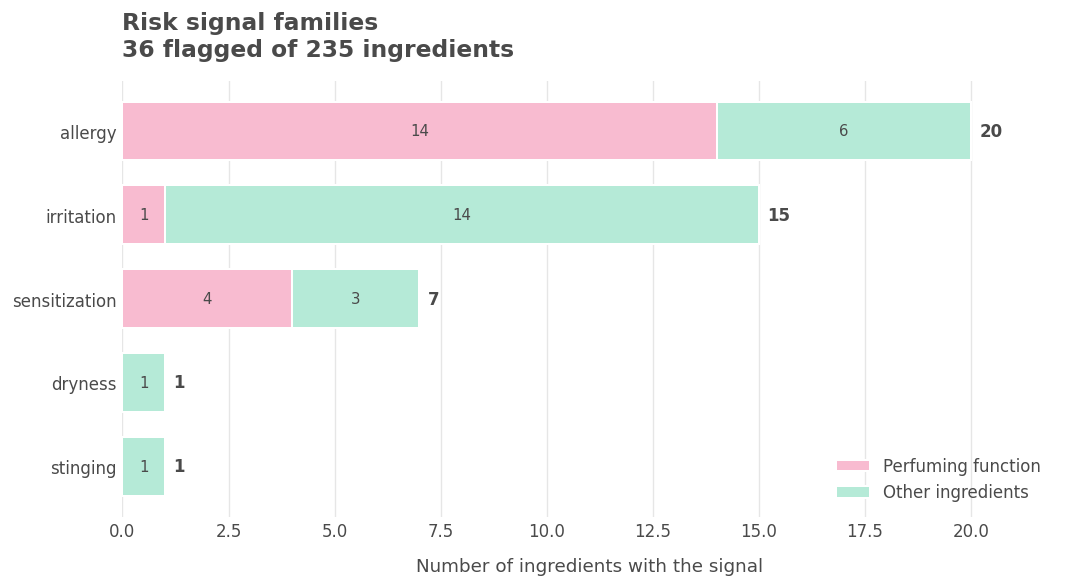

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

corp = pd.read_json("corpus.jsonl", lines=True)
corp["risk_signals"] = corp["risk_signals"].fillna("")

risky = corp[corp.risk_flag].copy()
risky["sig"] = risky.risk_signals.str.split(", ")
ex = risky.explode("sig")
ex = ex[ex.sig.str.strip() != ""]
ex["กลุ่ม"] = ex.is_perfuming.map({True: "perfuming", False: "ไม่ใช่ perfuming"})

# ตาราง: จำนวนสารที่พบแต่ละตระกูลสัญญาณ แยกตามกลุ่ม
tab = pd.crosstab(ex.sig, ex["กลุ่ม"])
tab["รวม"] = tab.sum(axis=1)
tab = tab.sort_values("รวม", ascending=False)
display(tab)

# ---------- กราฟ (ป้ายภาษาอังกฤษ เพราะ Colab ไม่มีฟอนต์ไทยใน matplotlib) ----------
PINK = "#F8BBD0"       # ชมพูพาสเทล
GREEN = "#B5EAD7"      # เขียวพาสเทล
TEXT = "#4A4A4A"
GRID = "#E6E6E6"

tab_plot = (
    tab.drop(columns="รวม")
       .rename(columns={"perfuming": "Perfuming function",
                        "ไม่ใช่ perfuming": "Other ingredients"})
       [["Perfuming function", "Other ingredients"]]   # กำหนดลำดับสีให้คงที่
       [::-1]
)

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
tab_plot.plot(kind="barh", stacked=True, ax=ax,
              color=[PINK, GREEN], width=0.7,
              edgecolor="white", linewidth=1.2)

# ใส่ตัวเลขกลางแต่ละช่วงของแท่ง (ข้ามค่า 0)
for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center",
                 fontsize=9, color=TEXT, fontweight="medium")

# ใส่ยอดรวมท้ายแท่ง
totals = tab_plot.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + totals.max() * 0.01, i, f"{int(total)}",
            va="center", ha="left", fontsize=10, color=TEXT, fontweight="bold")

# ตกแต่งแกนและกรอบ
ax.set_xlabel("Number of ingredients with the signal", fontsize=11, color=TEXT, labelpad=10)
ax.set_ylabel("")
ax.set_xlim(0, totals.max() * 1.1)
ax.tick_params(axis="both", colors=TEXT, length=0, labelsize=10)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)

# ชื่อกราฟ
ax.set_title(f"Risk signal families\n"
             f"{len(risky)} flagged of {len(corp)} ingredients",
             fontsize=14, color=TEXT, fontweight="bold", loc="left", pad=15)

# legend ไว้ด้านบนขวา ไม่มีกรอบ
ax.legend(title="", frameon=False, fontsize=10,
          loc="lower right", labelcolor=TEXT)

plt.tight_layout()
plt.show()

In [ ]:
corp = pd.read_json("corpus.jsonl", lines=True)
flagged = corp[corp.risk_flag].reset_index(drop=True)
print("จำนวนที่ติด risk_flag:", len(flagged), "\n")

for i, r in flagged.iterrows():
    print(f"[{i+1}] {r.ingredient_name} | สัญญาณ: {r.risk_signals}")
    print("    หลักฐาน:", r.risk_evidence[:350])
    print()

จำนวนที่ติด risk_flag: 36 

[1] Alpha-Isomethyl Ionone | สัญญาณ: allergy
    หลักฐาน: It’s a common fragrance ingredient that is one of the “EU 26 fragrances” that has to be labelled separately (and cannot be simply included in the term “fragrance/perfume” on the label) because of allergen potential.

[2] Parfum/​Fragrance | สัญญาณ: allergy
    หลักฐาน: It’s the number one cause of contact allergy to cosmetics. | It’s definitely a smart thing to avoid with sensitive skin (and fragrance of any type - natural is just as allergic as synthetic, if not worse!).

[3] DMDM Hydantoin | สัญญาณ: allergy
    หลักฐาน: Another potential issue is that formaldehyde-releasers might also release other things while reacting with amino acids in the skin that is probably the explanation why some people are not allergic to formaldehyde but are allergic to formaldehyde-releasing preservatives.

[4] Lavandula Angustifolia Oil | สัญญาณ: irritation, allergy
    หลักฐาน: (The main components of the flower essen

In [ ]:
from scipy.stats import fisher_exact

corp = pd.read_json("corpus.jsonl", lines=True)
flagged = corp[corp.risk_flag].reset_index(drop=True)

FALSE_POS = {5, 15, 23, 25, 26, 28, 31, 32, 33, 35}   # เลขข้อที่ตัดสินว่าไม่ใช่ (นับจาก 1)
flagged["human_label"] = [0 if (i + 1) in FALSE_POS else 1 for i in range(len(flagged))]

n, tp = len(flagged), int(flagged.human_label.sum())
print(f"Precision ของ risk_flag: {tp}/{n} = {tp/n*100:.0f}%")
print("แยกตามกลุ่ม:")
print(flagged.groupby("is_perfuming").human_label.agg(flagged="count", true_risk="sum"))

# ยืนยันผลเปรียบเทียบกลุ่มด้วยป้ายที่ตรวจแล้ว
corp = corp.merge(flagged[["url", "human_label"]], on="url", how="left")
corp["verified_risk"] = corp.human_label.fillna(0).astype(int) == 1

a = int((corp.is_perfuming & corp.verified_risk).sum());   b = int((corp.is_perfuming & ~corp.verified_risk).sum())
c = int((~corp.is_perfuming & corp.verified_risk).sum());  d = int((~corp.is_perfuming & ~corp.verified_risk).sum())
_, p = fisher_exact([[a, b], [c, d]])
print(f"\nหลังตรวจมือ: perfuming เสี่ยงจริง {a}/{a+b} ({a/(a+b)*100:.1f}%) | อื่น ๆ {c}/{c+d} ({c/(c+d)*100:.1f}%) | Fisher p = {p:.4g}")
print(f"เสี่ยงจริงทั้งหมด {a+c}/{len(corp)} ({(a+c)/len(corp)*100:.1f}%)")

Precision ของ risk_flag: 26/36 = 72%
แยกตามกลุ่ม:
              flagged  true_risk
is_perfuming                    
False              21         11
True               15         15

หลังตรวจมือ: perfuming เสี่ยงจริง 15/36 (41.7%) | อื่น ๆ 11/199 (5.5%) | Fisher p = 8.417e-08
เสี่ยงจริงทั้งหมด 26/235 (11.1%)


**สิ่งที่พบ**

- จาก 235 ส่วนผสม ระบบจับคำพบสัญญาณ 36 รายการ ตรวจมือแล้วเป็นความเสี่ยงจริง 26 รายการ (precision 72%) คิดเป็น 11.1% ของตัวอย่าง

- สารที่ระบุหน้าที่ perfuming มีข้อความเสี่ยงจริง 15/36 (41.7%) ส่วนสารอื่น 11/199 (5.5%) ต่างกันประมาณ 7 เท่า (Fisher p < 0.001)

- ทั้ง 15 รายการของกลุ่ม perfuming ที่ถูกจับ ตรวจแล้วเป็นความเสี่ยงจริงทั้งหมด และ 14 ใน 15 เป็นสัญญาณประเภท การแพ้ (allergy) เช่น ข้อความว่าเป็น "EU 26 fragrances" ที่ต้องแจ้งแยกบนฉลากเพราะมีศักยภาพก่อภูมิแพ้

- สัญญาณในสารกลุ่มอื่น (เช่น Methylisothiazolinone, Glycolic Acid, Benzoyl Peroxide, Propylene Glycol) เป็นเรื่องการระคายเคืองหรือไวต่อการกระตุ้น และมักผูกกับความเข้มข้นหรือค่า pH

- กลุ่ม preservative ไม่ต่างจากสารอื่นอย่างมีนัยสำคัญ (3/14 เทียบ 33/221, p = 0.46) จึงไม่สรุปว่าสูงกว่า

- กลุ่มที่มีตัวอย่างน้อยกว่า 10 รายการไม่นำมาเปรียบเทียบ

**ข้อจำกัด:** ตัวอย่างเป็นรายการที่คัดเอง และตัวชี้วัดมาจากข้อความของเว็บเดียว (precision 72%) ใช้เทียบระหว่างกลุ่มในตัวอย่างนี้ ไม่ใช่อัตราของตลาดทั้งหมด

##**3.4 Insight Card ของ Part 3**

**Insight:**	ในตัวอย่าง 235 ส่วนผสม สารที่ระบุหน้าที่ perfuming เป็นกลุ่มที่มีข้อความระบุความเสี่ยงแพ้/ระคายเคืองสูงที่สุด และความเสี่ยงของกลุ่มนี้เป็นประเภท การแพ้ เป็นหลัก

**หลักฐาน:**
1) ตรวจมือแล้ว perfuming เสี่ยงจริง 15/36 (41.7%) เทียบกับสารกลุ่มอื่น 11/199 (5.5%), Fisher p = 8.4×10⁻⁸

2) สัญญาณ allergy พบใน 14 จาก 15 รายการ perfuming ที่ติด risk (เช่น Citral, Coumarin, Farnesol, Linalool, Limonene)

3) กลุ่ม preservative พบความเสี่ยง 3/14 รายการ (21.4%) เทียบกับกลุ่มอื่นที่ไม่ใช่ preservative 33/221 รายการ (14.9%) ซึ่งต่างกันอย่างไม่มีนัยสำคัญทางสถิติ ($p = 0.46$)  

4) ภาพรวมทั้งตัวอย่าง พบสารที่มีความเสี่ยงจริง 26/235 รายการ (11.1%)

**So what:**

ถ้าทีมพัฒนาผลิตภัณฑ์ต้องระวังเรื่องการแพ้/ระคายเคือง ควรเริ่มตรวจที่ส่วนผสมกลุ่ม perfuming ก่อน เพราะสัดส่วนสูงกว่าสารอื่นหลายเท่า และข้อความที่พบเป็นการเตือนเรื่องการแพ้โดยตรง

**Action:**

**ทีม R&D:** สูตรสำหรับผิวแพ้ง่ายให้ตั้งเป้า fragrance-free และไม่ใช้สารในรายการ EU 26 ที่พบในชุดข้อมูล สำหรับสารที่ไม่ใช่น้ำหอมแต่มีข้อความเสี่ยง (เช่น กรด สารกันเสียบางตัว) ให้ระบุความเข้มข้นสูงสุดและค่า pH ก่อนใช้

**ทีม QA:** ใช้รายชื่อ 26 สารที่ตรวจยืนยันแล้วเป็น checklist เบื้องต้นในการคัดกรองวัตถุดิบ แล้วเพิ่มการตรวจสอบเอกสารข้อมูลความปลอดภัยของผู้ขายเฉพาะรายการเหล่านั้น

**ความมั่นใจ:**	**ปานกลาง**

สิ่งที่ทำให้มั่นใจ:
- ผลสัดส่วนความเสี่ยงของกลุ่ม perfuming สูงกว่ากลุ่มอื่นอย่างมีนัยสำคัญ ($41.7\%$ vs $5.5\%$, Fisher $p < 0.001$) และผ่านการตรวจประโยคหลักฐานด้วยมือครบทั้ง 36 รายการ
- สารในกลุ่ม perfuming ที่ติด risk_flag ตรงกับรายการสารก่อภูมิแพ้ตามกฎหมาย (EU 26 fragrance allergens) ถึง 14 จาก 15 รายการ

สิ่งที่ทำให้ไม่มั่นใจ:
- ชุดข้อมูลเป็นตัวอย่างที่เลือกเอง ($N = 235$) ไม่ได้แทนตลาดสกินแคร์ทั้งหมด
- ตัวชี้วัดมาจากข้อความของเว็บเดียวไม่ใช่ผลทดสอบทางคลินิก (Precision การจับคำอยู่ที่ $72\%$)   
- มีสารกลุ่มน้ำหอมบางตัวถูกตัดทิ้งเพราะไม่มีข้อความคำอธิบายบนหน้าเว็บ (เช่น Cinnamal, Isoeugenol)   

**ข้อมูลชุดนี้ยังตอบอะไรไม่ได้ และถ้าจะตอบต้องมีข้อมูลอะไรเพิ่ม**


1.   สารตัวไหนระคายเคืองหรือแพ้จริงกับผิวคน
ยังตอบไม่ได้ เพราะ risk_flag มาจากการจับคำในข้อความของเว็บเดียว (ตรวจมือแล้วแม่นประมาณ 72%) ไม่ใช่ผลทดสอบกับคนจริง

     **ข้อมูลที่ต้องเก็บเพิ่ม**: ผล patch test หรืออัตราการเกิดอาการ (% ของผู้ทดสอบ) จากฐานข้อมูลความปลอดภัย เช่น CIR และ SCCS

2.   ความเสี่ยงต่างกันตามรูปแบบการใช้หรือไม่
ยังตอบไม่ได้ เพราะไม่มีข้อมูลว่าผลิตภัณฑ์ล้างออกหรือทิ้งไว้บนผิว

     **ข้อมูลที่ต้องเก็บเพิ่ม**: ประเภทผลิตภัณฑ์ (leave-on หรือ wash-off) และระยะเวลาที่สัมผัสผิว

3. สูตรสำเร็จรูปจะเสี่ยงแค่ไหน
ยังตอบไม่ได้ เพราะข้อมูลเป็นระดับสารเดี่ยว ไม่มีความเข้มข้น ค่า pH หรือปฏิกิริยาระหว่างสาร

     **ข้อมูลที่ต้องเก็บเพิ่ม**: ความเข้มข้นที่ใช้จริงและความเข้มข้นสูงสุดที่แนะนำ ค่า pH ของสูตร และรายการส่วนผสมของผลิตภัณฑ์จริง

4. ความเสี่ยงของสารน้ำหอมบางตัว
ยังตอบไม่ครบ เพราะมี 33 รายการถูกตัดออก เนื่องจากหน้าเว็บมีแค่ข้อมูลทางการ CosIng ไม่มีคำอธิบาย (รวม cinnamal, isoeugenol และ cinnamyl alcohol ซึ่งอยู่ในรายการ EU 26)

     **ข้อมูลที่ต้องเก็บเพิ่ม**: ข้อความจากแหล่งอื่น เช่น เอกสารของ SCCS เพื่อให้กลุ่มน้ำหอมครบ


